# Data Insights and Predictions in Formula 1 Races

Authors: Jameson Cohen, Quinn Donovan, Anthony Fletcher, and Trey Whitehead

Project Group: 98

Kaggle Data: https://www.kaggle.com/datasets/rohanrao/formula-1-world-championship-1950-2020/data

Original Notebook: https://colab.research.google.com/drive/1OrYjiKQSh0ExFJ-E5OOTxoTZBnb31TkW#scrollTo=m2HjjyYc0aHn





# Table of Contents + Model Flow-Chart

<details>
<summary><strong>Section 1: Overview</strong></summary>

- **1.1** Introduction  
- **1.2** Research Question  
- **1.3** Our Approach  

</details>

---

<details>
<summary><strong>Section 2: Exploratory Data Analysis</strong></summary>

- **2.1** Preparing the Dataset  

  <summary>2.1.1 Initial Dataset Information</summary>
  
- **2.2** Initial Dataset Summary  
- **2.3** Additional Pre-Processing and Predictor Creation  
  <summary>2.3.1 Merging Relevant Dataframes</summary>

  <summary>2.3.2 Constructor Car Strength Score Creation</summary>

  <summary>2.3.3 Constructor Pit Stop Strength Score Creation</summary>

  <summary>2.3.4 Elo Scores</summary>

  <summary>2.3.5 Position Buckets</summary>
  
- **2.4** Model Data Summary  

</details>

---

<details>
<summary><strong>Section 3: Exploratory Data Analysis (EDA)</strong></summary>

- **3.1** Constructor Strength Score and Pitstop Score by Round  
  <summary>Constructor Season Strength Score</summary>
  
- **3.2** Pit-Stop Data by Team and by Season  
- **3.3** Importance of Grid Position on Final Results  
- **3.4** Points by Constructor  
- **3.5** Elo Scores over Time  

</details>

---

<details>
<summary><strong>Section 4: Models</strong></summary>

- **4.1** Modeling Overview  
  <summary>4.1.1 Universal Train-Val-Test Split</summary>

  <summary>4.1.2 Defining a Results Dictionary</summary>

- **4.2** Majority Classification  
  <summary>4.2.1 Motivation and Description</summary>

  <summary>4.2.2 Code</summary>

  <summary>4.2.3 Results</summary>

- **4.3** Logistic Regression  
  <summary>4.3.1 Motivation and Description of Logistic Regression</summary>

  <summary>4.3.2 Code</summary>

  <summary>4.3.3 Results</summary>

- **4.4** Bagging  
  <summary>4.4.1 Motivation and Description</summary>

  <summary>4.4.2 Code</summary>

  <summary>4.4.3 Results</summary>

- **4.5** Random Forest  
  <summary>4.5.1 Motivation and Description</summary>

  <summary>4.5.2 Code</summary>

  <summary>4.5.3 Results</summary>

- **4.6** AdaBoost  
  <summary>4.6.1 Motivation and Description</summary>

  <summary>4.6.2 Code</summary>

  <summary>4.6.3 Results</summary>


- **4.7** XGBoost  
  <summary>4.7.1 Motivation and Description</summary>

  <summary>4.7.2 Code</summary>

  <summary>4.7.3 Results</summary>

</details>

---

<summary><strong>Section 5: Results and Discussion</strong></summary>

---

<summary><strong>Section 6: Conclusion</strong></summary>

---

<summary><strong>Section 7: Acknowledgements</strong></summary>


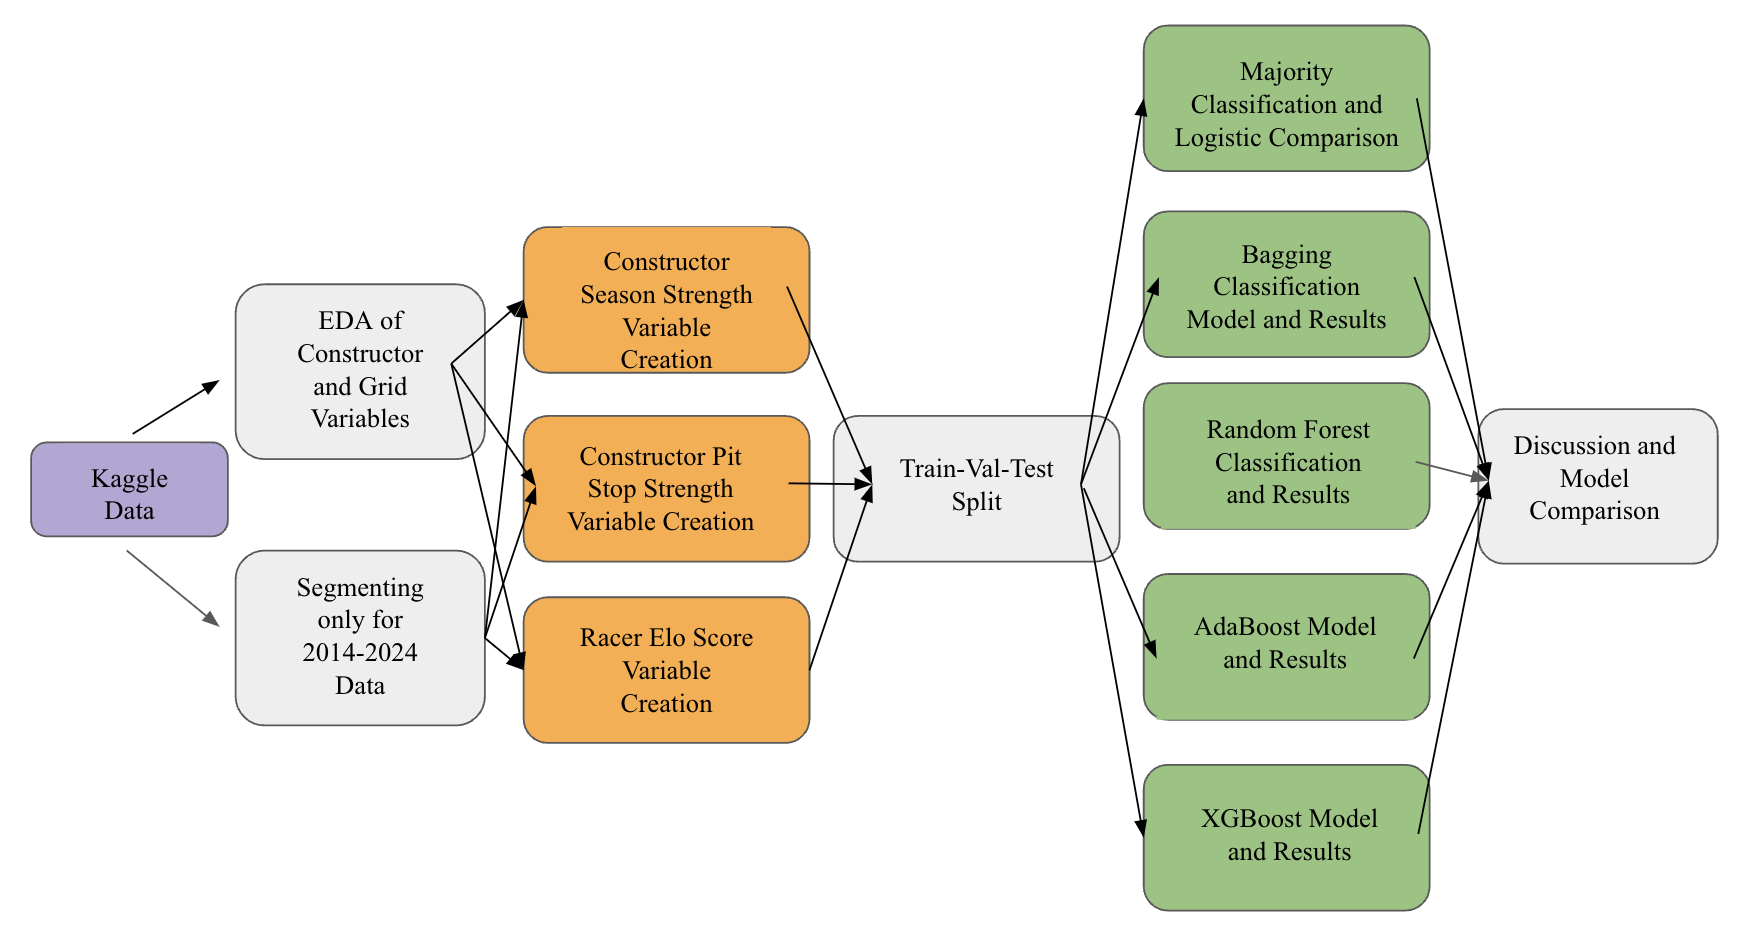

# SECTION 1: OVERVIEW

## 1.1: Introduction
<a id="introduction"></a>
New introduction: Forbes reports that Formula One drew in a record-setting number of fans in $2023$, exceeding its pre-COVID totals. Exploding in popularity, Formula One stands at the intersection of sport and technology, captivating global audiences with its high-speed thrills and cutting-edge innovation. As teams push the limits of engineering and strategy, F1's future looks brighter than ever; as new fans and budding data scientists, we want to model what determines F1 success on a season-by-season basis. We want to figure out who is poised to win.

## 1.2: Research Question

Leveraging historical performance data, constructor strength, and various driver attributes, can we reliably predict with over 70% accuracy the quartile in which an F1 driver will finish during a given race?

## 1.3 The General Approach
<a id="ga"></a>
We begin by investigating our collection of csv files, building dataframes with relevant information, and conducting exploratory data analysis (EDA). Then, we create several new predictors from our dataframes that enhance the strength of our subsequent models. Simultaneously, we categorize drivers' finishing positions into four quartiles based on their rank, which enables us to develop our primary target variable. With the new response variable, several abstracted features, and other pertinent predictors, we begin building a series of predictive models. Generally, our training dataset holds all information between 2014 and 2022, our validation set is the 2023 season, and we test on the 2024 circuit. For The models have been outlined below. Please note, for some models, like our bagging model, do not require a separate validation set and instead focus on metrics like OOB error:

1. Majority Classification

2. Logistic Regression

3. Bagging Model

4. Random Forest

5. AdaBoost

6. XGBoost

As we test each classification model, we report each model's accuracy scores and other relevant metrics. We store these models in a dictionary that we iteratively supplement as we finish each formulation.

In our results and analysis section, we discuss the strengths and weaknesses of each model. We include relevant graphics that highlight the discrepancies in model variation and performance, and we propose our theory for F1 race prediction.

# SECTION 2: EXPLORATORY DATA ANALYSIS

## 2.1: Preparing the Dataset

In [57]:
import os
import numpy as np
import kagglehub
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import folium
from IPython.display import display
from matplotlib.lines import Line2D
import matplotlib.cm as cm
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.utils import resample
from scipy.stats import mode
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score
from sklearn.calibration import calibration_curve
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
from sklearn.pipeline import make_pipeline
from xgboost import XGBClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.preprocessing import StandardScaler

In [58]:
path = kagglehub.dataset_download("rohanrao/formula-1-world-championship-1950-2020")
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]
dataframes = {}
for csv_file in csv_files:
    file_path = os.path.join(path, csv_file)
    dataframes[csv_file] = pd.read_csv(file_path)

In [59]:
def replace_substring_with_null(dataframes, substring='\\N'):
    for df_name, df in dataframes.items():
        df.replace(substring, np.nan, inplace=True)
    return dataframes

updated_dataframes = replace_substring_with_null(dataframes, substring='\\N')

In [60]:
def reclassify_data_types(dataframes):
    modified_dataframes = {}

    for df_name, df in dataframes.items():

        # Convert some columns to numeric
        for num_col in ['milliseconds', 'position', 'fastestLap', 'rank']:
            if num_col in df.columns:
                df[num_col] = pd.to_numeric(df[num_col], errors='coerce')

        # Convert some  columns to categorical
        for cat_col in ['constructorRef', 'nationality']:
            if cat_col in df.columns:
                df[cat_col] = df[cat_col].astype('category')

        modified_dataframes[df_name] = df

    return modified_dataframes

# Unhide output to see new classification
modified_dataframes = reclassify_data_types(updated_dataframes)

### 2.1.1: Inital Dataset Information

In [61]:
for csv in csv_files:
    print(f"{csv}")
    display(modified_dataframes[csv].head(5))

for csv in csv_files:
    print(f"{csv}")
    print(f"{modified_dataframes[csv].columns}\n")

constructor_results.csv


,constructorResultsId,raceId,constructorId,points,status
0,1,18,1,14.0,NaN
1,2,18,2,8.0,NaN
2,3,18,3,9.0,NaN
3,4,18,4,5.0,NaN
4,5,18,5,2.0,NaN


constructors.csv


,constructorId,constructorRef,name,nationality,url
0,1,mclaren,McLaren,British,http://en.wikipedia.org/wiki/McLaren
1,2,bmw_sauber,BMW Sauber,German,http://en.wikipedia.org/wiki/BMW_Sauber
2,3,williams,Williams,British,http://en.wikipedia.org/wiki/Williams_Grand_Pr...
3,4,renault,Renault,French,http://en.wikipedia.org/wiki/Renault_in_Formul...
4,5,toro_rosso,Toro Rosso,Italian,http://en.wikipedia.org/wiki/Scuderia_Toro_Rosso


sprint_results.csv


...

driver_standings.csv


,driverStandingsId,raceId,driverId,points,position,positionText,wins
0,1,18,1,10.0,1,1,1
1,2,18,2,8.0,2,2,0
2,3,18,3,6.0,3,3,0
3,4,18,4,5.0,4,4,0
4,5,18,5,4.0,5,5,0


races.csv


,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
0,1,2009,1,1,Australian Grand Prix,2009-03-29,06:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2009,2,2,Malaysian Grand Prix,2009-04-05,09:00:00,http://en.wikipedia.org/wiki/2009_Malaysian_Gr...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2009,3,17,Chinese Grand Prix,2009-04-19,07:00:00,http://en.wikipedia.org/wiki/2009_Chinese_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2009,4,3,Bahrain Grand Prix,2009-04-26,12:00:00,http://en.wikipedia.org/wiki/2009_Bahrain_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2009,5,4,Spanish Grand Prix,2009-05-10,12:00:00,http://en.wikipedia.org/wiki/2009_Spanish_Gran...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


constructor_results.csv
Index(['constructorResultsId', 'raceId', 'constructorId', 'points', 'status'], dtype='object')

constructors.csv
Index(['constructorId', 'constructorRef', 'name', 'nationality', 'url'], dtype='object')

sprint_results.csv
Index(['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid',
       'position', 'positionText', 'positionOrder', 'points', 'laps', 'time',
       'milliseconds', 'fastestLap', 'fastestLapTime', 'statusId'],
      dtype='object')

pit_stops.csv
Index(['raceId', 'driverId', 'stop', 'lap', 'time', 'duration',
       'milliseconds'],
      dtype='object')

lap_times.csv
Index(['raceId', 'driverId', 'lap', 'position', 'time', 'milliseconds'], dtype='object')

results.csv
Index(['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid',
       'position', 'positionText', 'positionOrder', 'points', 'laps', 'time',
       'milliseconds', 'fastestLap', 'rank', 'fastestLapTime',
       'fastestLapSpeed', 'statusId'],
      dtype=

## 2.2: Initial Dataset Summary

The data analyzed below is intuitive as to what it contains: each csv contains some subset of the F1 World Championship data between the years 1950-2020 with data on 1000+ races, 100+ different drivers, 40+ constructors including results on every qualifying and sprint result during that time period. As shown below, we loaded the data from these 14 different csvs and experimented with basic exploratory data analysis by plotting the locations for a few circuits using a geographic Folium display.

There are 2 key types of missing data in our entire dataset; all the missing data are null entries but their string representation varies. Therefore, to fully remove and find all these datatypes within the dataset we recast all missing data to have NaN as their entry. With all the missing data represented the same, we were able to identify that there were 29 different columns with missing data, ranging from as few as 6 entries to as many as 18,986. Most of the columns with significant missing entries are in the results.csv, notably the sprint.csv which contains the results to the sprint races does not have nearly as many missing data which may pose particular natural path of focus.

We do not find any examples of data imbalance at this point in time based on our brief analysis on the number of different races that occurred each year as the number of seasons has remained consistently 1 in the data. As a result, we plan to investigate further to ensure that our train and validation data will be proportional in their length, but our belief is that one season for every year ensures that comparing drivers over one season will be consistent enough to draw conclusions.

We do not find any examples of data scaling in this data given that races have remained consistent in their range of distances beyond 1958. We may exclude the data between 1950 and 1957 if we find it to contribute a significant bias to our data given that Grand Prix races were traditionally longer during that time period.

To address the data missingness we plan to primarily reconsider the general scope of questions we will focus on. For example, we will determine which driver attributes/performance metrics to consider, and which resutls we want to validate them against. A bulk of the missingness is centered around fastest lap time/lap speed and we may not utilize these metrics to determine the performance of the driver. Likewise, we will determine where in the data the missing position resutls come from to decide if there is a particular time period over which we want to focus our model to better train on more complete season data, if we view that approach as valid.

## 2.3 Additional Pre-Processing and Predictor Creation

### 2.3.1: Merging Relevant Dataframes

In [62]:
pd.set_option('display.max_columns', None)

qualifying = modified_dataframes['qualifying.csv']
results = modified_dataframes['results.csv']
pit_stops = modified_dataframes['pit_stops.csv']
constructor_standings = modified_dataframes['constructor_standings.csv']
constructors = modified_dataframes['constructors.csv']
results = modified_dataframes['results.csv']
drivers = modified_dataframes['drivers.csv']
constructors = modified_dataframes['constructors.csv']
races = modified_dataframes['races.csv']
circuits = modified_dataframes['circuits.csv']
status = modified_dataframes['status.csv']

# Merge qualifying and results to get driver's starting position and final position
qualifying_results = pd.merge(qualifying, results, on=['raceId', 'driverId'], how='inner')

# Calculate position change (final position - starting position)
qualifying_results['position_change'] = qualifying_results['position_x'] - qualifying_results['grid']

# Merge pit stop data (total number of pit stops and total pit stop time)
pit_stop_summary = pit_stops.groupby(['raceId', 'driverId']).agg(
    pit_stop_count=('lap', 'nunique'),
    total_pit_stop_time=('milliseconds', 'sum')
).reset_index()


# Merge constructor standings (total constructor points)
constructor_standings = constructor_standings.rename(columns={'points': 'constructorPoints'})

constructor_summary = constructor_standings[['raceId', 'constructorId', 'constructorPoints']]
constructor_summary = pd.merge(constructor_summary, constructors[['constructorId', 'name']], on='constructorId', how='left')

# Merge everything into a single df
model_data = pd.merge(qualifying_results, pit_stop_summary, on=['raceId', 'driverId'], how='inner')
model_data = pd.merge(model_data, constructor_summary, on='raceId', how='left')

model_data=model_data.drop(columns=['constructorId', 'name'])
model_data=model_data.drop_duplicates()
model_data = model_data.merge(races[['raceId', 'year', 'round']], on='raceId', how='left')
model_data = model_data.drop_duplicates(subset=['qualifyId', 'raceId', 'driverId'])
model_data

,qualifyId,raceId,driverId,constructorId_x,number_x,position_x,q1,q2,q3,resultId,constructorId_y,number_y,grid,position_y,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,position_change,pit_stop_count,total_pit_stop_time,constructorPoints,year,round
0,4537,841,20,9,1,1,1:25.296,1:24.090,1:23.529,20779,9,1,1,1.0,1,1,25.0,58,1:29:30.259,5370259.0,44.0,4.0,1:29.844,212.488,1,0,2,46639,0.0,2011,1
7,4538,841,1,1,3,2,1:25.384,1:24.595,1:24.307,20780,1,3,2,2.0,2,2,18.0,58,+22.297,5392556.0,41.0,8.0,1:30.314,211.382,1,0,2,46426,0.0,2011,1
14,4539,841,17,9,2,3,1:25.900,1:24.658,1:24.395,20783,9,2,3,5.0,5,5,10.0,58,+38.171,5408430.0,50.0,3.0,1:29.600,213.066,1,0,3,72176,0.0,2011,1
21,4540,841,18,1,4,4,1:25.886,1:24.957,1:24.779,20784,1,4,4,6.0,6,6,8.0,58,+54.304,5424563.0,49.0,5.0,1:29.883,212.396,1,0,3,62851,0.0,2011,1
28,4541,841,4,6,5,5,1:25.707,1:25.242,1:24.974,20782,6,5,5,4.0,4,4,12.0,58,+31.772,5402031.0,49.0,2.0,1:29.487,213.336,1,0,3,72165,0.0,2011,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50793,10306,1132,817,215,3,15,1:31.291,1:27.949,NaN,26517,215,3,15,13.0,13,13,0.0,51,NaN,NaN,47.0,15.0,1:30.735,233.731,11,0,2,58748,373.0,2024,12
50803,10307,1132,822,15,77,16,1:32.431,NaN,NaN,26519,15,77,16,15.0,15,15,0.0,51,NaN,NaN,44.0,18.0,1:31.277,232.343,11,0,2,62155,373.0,2024,12
50813,10308,1132,825,210,20,17,1:32.905,NaN,NaN,26516,210,20,17,12.0,12,12,0.0,52,+1:30.153,5037212.0,42.0,13.0,1:30.093,235.396,1,0,2,60192,373.0,2024,12
50823,10309,1132,839,214,31,18,1:34.557,NaN,NaN,26520,214,31,18,16.0,16,16,0.0,50,NaN,NaN,46.0,16.0,1:30.875,233.371,12,0,4,115146,373.0,2024,12


### 2.3.2 Constructor Car Strength Score Creation
This variable is created by taking the average qualifying lap time for each constructor's racer and stadnerdizing their average time amoung the rest of the constructors.  Then, for each race, this scores is averaged across all the races that have taken place that season and before the race in question.  This is done to only include past information in our model.

The average normalized scores are then averaged acorss each season to provide a metric for a constructor's car strength that season.  This meteric provides insight into the advnatage of a constructor's  which may have much better technology than their competitors.  We belive that the Q1 lap time is a strong meteric becasue racers are aiming for the highest posssible lap time, have fresh tires, and have equal car weight.


In [63]:
def convert_time_to_seconds(time_str):
    if pd.isna(time_str):
        return None
    minutes, seconds = time_str.split(':')
    return int(minutes) * 60 + float(seconds)
try:
    model_data['q1'] = model_data['q1'].apply(convert_time_to_seconds)
    model_data['q2'] = model_data['q2'].apply(convert_time_to_seconds)
    model_data['q3'] = model_data['q3'].apply(convert_time_to_seconds)
except:
    pass

# Calculate the average q1 for each group of raceId and constructorId_x

# Standardize the q1 for each raceId from 0-1 where 1 is the fastest time for drivers
def get_best_time(row):
    if not pd.isna(row['q3']):
        return row['q3']
    elif not pd.isna(row['q2']):
        return row['q2']
    else:
        return row['q1']

model_data['best_time'] = model_data.apply(get_best_time, axis=1)

model_data['driverSpreadRace'] = model_data.groupby('raceId')['best_time'].transform(lambda x: (x.max() - x) / (x.max() - x.min()))


model_data['driverSpreadSeason'] = model_data.apply(lambda row: model_data[(model_data['year'] == row['year']) &
                                                                           (model_data['driverId'] == row['driverId']) &
                                                                           (model_data['round'] < row['round'])]['driverSpreadRace'].mean(), axis=1)



model_data['averageQ1'] = model_data.groupby(['raceId', 'constructorId_x'])['q1'].transform('mean')

# Standardize the averageQ1 for each raceId from 0-1 where 1 is the fastest time
model_data['standardTeamCarScoreByRace'] = model_data.groupby('raceId')['averageQ1'].transform(lambda x: (x.max() - x) / (x.max() - x.min()))
model_data['constructorSeasonStrengthScore'] = 0
# Add a column called seasonStrength which averages eachScore by constructorId_x for each year
model_data['constructorSeasonStrengthScore'] = model_data.apply(lambda row: model_data[(model_data['year'] == row['year']) &
                                                                                       (model_data['constructorId_x'] == row['constructorId_x']) &
                                                                                       (model_data['round'] < row['round'])]['standardTeamCarScoreByRace'].mean() if not model_data[(model_data['year'] == row['year']) &
                                                                                       (model_data['constructorId_x'] == row['constructorId_x']) &
                                                                                       (model_data['round'] < row['round'])].empty else 0, axis=1)

# Add a column `lastYearStrength`
def get_last_year_strength(row, model_data):
    last_year = row['year'] - 1
    constructor_id = row['constructorId_x']

    # Find the last round's strength score from the previous year
    last_year_data = model_data[(model_data['year'] == last_year) &
                                (model_data['constructorId_x'] == constructor_id)]
    if not last_year_data.empty:
        # Get the score for the last round of the previous year
        last_year_last_round = last_year_data[last_year_data['round'] == last_year_data['round'].max()]
        if not last_year_last_round.empty:
            return last_year_last_round['constructorSeasonStrengthScore'].values[0]

    # If not available, take the average of the current year's strength score
    current_year_data = model_data[(model_data['year'] == row['year']) &
                                   (model_data['constructorId_x'] == constructor_id) &
                                   (model_data['round'] <= row['round'])]
    if not current_year_data.empty:
        return current_year_data['constructorSeasonStrengthScore'].mean()

    # Default to 0 if no data is available
    return 0

# Apply the function row-wise
model_data['lastYearStrength'] = model_data.apply(lambda row: get_last_year_strength(row, model_data), axis=1)

# Ensure the data is sorted by year, round, and driverId
model_data = model_data.sort_values(by=['driverId', 'year', 'round']).reset_index(drop=True)

# Function to calculate momentum as the average of the last 3 positions
def calculate_racer_momentum(row, model_data):
    driver_id = row['driverId']
    year = row['year']
    round_num = row['round']

    # Get the last three races before the current race
    last_three_races = model_data[(model_data['driverId'] == driver_id) &
                                  ((model_data['year'] < year) |
                                   ((model_data['year'] == year) & (model_data['round'] < round_num)))]

    last_three_races = last_three_races.sort_values(by=['year', 'round'], ascending=False).head(3)

    if not last_three_races.empty:
        return last_three_races['positionOrder'].mean()  # Replace 'positionOrder' with the column for position
    return None  # Default to None if no previous races are available

# Apply the function row-wise
model_data['racerMomentum'] = model_data.apply(lambda row: calculate_racer_momentum(row, model_data), axis=1)


### 2.3.4: Constructor Pit Stop Strength Score Creation
This variable gives insight into team strength by seeing how well each constructor is at preforming pit stops by looking at theier average pit stop times.  We use the same methodology as Constructor Car Strength Score to create this variable.  Naturally, the distributions of the two look similar.

In [64]:
model_data['averagePitStopTime'] = model_data['total_pit_stop_time'] / model_data['pit_stop_count']
model_data['averageTeamPitStopTimePerRace'] = model_data.groupby(['raceId', 'constructorId_x'])['averagePitStopTime'].transform('mean')
model_data['standarizedPitStopTeamScore'] = model_data.groupby('raceId')['averageTeamPitStopTimePerRace'].transform(lambda x: (x.max() - x) / (x.max() - x.min()))
# Add a column called seasonStrength which averages eachScore by constructorId_x for each year
model_data['constructorSeasonPitStopStrengthScore'] = 0
model_data['constructorSeasonPitStopStrengthScore'] = model_data.apply(lambda row: model_data[(model_data['year'] == row['year']) &
                                                                                       (model_data['constructorId_x'] == row['constructorId_x']) &
                                                                                       (model_data['round'] < row['round'])]['standarizedPitStopTeamScore'].mean() if not model_data[(model_data['year'] == row['year']) &
                                                                                       (model_data['constructorId_x'] == row['constructorId_x']) &
                                                                                       (model_data['round'] < row['round'])].empty else 0, axis=1)


### 2.3.5: Elo Scores

In [65]:
# Initialize a dictionary to store Elo scores by driverId
elo_scores = {}

# K factor
# Chose to go slower because of sheer number of updates after each race
K = 5

# Function to calculate and update Elo ratings
def update_elo(winner_id, loser_id, elo_scores, K=K):
    winner_elo = elo_scores.get(winner_id, 1500)
    loser_elo = elo_scores.get(loser_id, 1500)
    expected_winner = 1 / (1 + 10 ** ((loser_elo - winner_elo) / 400))
    expected_loser = 1 / (1 + 10 ** ((winner_elo - loser_elo) / 400))
    elo_scores[winner_id] = winner_elo + K * (1 - expected_winner)
    elo_scores[loser_id] = loser_elo + K * (0 - expected_loser)

# Loop over model_data to update Elo scores after each race
for race_id in model_data['raceId'].unique():
    race_data = model_data[model_data['raceId'] == race_id]

    for _, row in race_data.iterrows():
        driver_id = row['driverId']
        position = row['position_y']

        # Get all other drivers in the same race
        other_drivers = race_data[race_data['driverId'] != driver_id]

        for _, other_row in other_drivers.iterrows():
            other_driver_id = other_row['driverId']
            other_position = other_row['position_y']

            # Update Elo scores based on position comparison
            if position == 1:
                update_elo(driver_id, other_driver_id, elo_scores)
            elif other_position == 1:
                update_elo(other_driver_id, driver_id, elo_scores)
            elif position < other_position:
                update_elo(driver_id, other_driver_id, elo_scores)
            elif position > other_position:
                update_elo(other_driver_id, driver_id, elo_scores)

        # Update Elo by race
        model_data.loc[(model_data['driverId'] == driver_id) & (model_data['raceId'] == race_id), 'elo_score'] = elo_scores[driver_id]

### 2.3.6: Position Buckets

As outlined above, our buckets are imperfect, because the number of competitors in a given race varies over time, and often, the field is not divisible by 4. For this reason, our last bucket has more entries than any other.

In [66]:
# Function to categorize position into buckets
def categorize_position(row):
    total_drivers = len(model_data[model_data['raceId'] == row['raceId']])
    bucket_size = total_drivers // 4

    # Divide drivers into 4 buckets based on position
    if row['position_y'] <= bucket_size:
        return 0  # Top bucket
    elif row['position_y'] <= 2 * bucket_size:
        return 1  # Second bucket
    elif row['position_y'] <= 3 * bucket_size:
        return 2  # Third bucket
    else:
        return 3  # Bottom bucket

# Apply the position bucket categorization
model_data['position_bucket'] = model_data.apply(categorize_position, axis=1)

# Display updated model_data with elo_score and position_bucket
print(model_data[['driverId', 'raceId', 'position_y', 'elo_score', 'position_bucket']].head())

   driverId  raceId  position_y    elo_score  position_bucket
0         1     841         2.0  1526.311531                0
1         1     842         8.0  1550.138258                1
2         1     843         1.0  1595.487580                0
3         1     844         4.0  1650.419531                0
4         1     845         2.0  1686.641108                0


In [67]:
print(model_data[['driverId', 'position_x','position_y', 'position_bucket']].head())

   driverId  position_x  position_y  position_bucket
0         1           2         2.0                0
1         1           2         8.0                1
2         1           3         1.0                0
3         1           4         4.0                0
4         1           3         2.0                0


In [68]:
model_data['position_bucket'].value_counts()

,count
position_bucket,
3,1639
0,1231
1,1229
2,1227


### 2.4: Model Data Summary

In [69]:
model_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5326 entries, 0 to 5325
Data columns (total 45 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   qualifyId                              5326 non-null   int64  
 1   raceId                                 5326 non-null   int64  
 2   driverId                               5326 non-null   int64  
 3   constructorId_x                        5326 non-null   int64  
 4   number_x                               5326 non-null   int64  
 5   position_x                             5326 non-null   int64  
 6   q1                                     5275 non-null   float64
 7   q2                                     3910 non-null   float64
 8   q3                                     2489 non-null   float64
 9   resultId                               5326 non-null   int64  
 10  constructorId_y                        5326 non-null   int64  
 11  numb

# SECTION 3: EDA

## 3.1: Constructor Strength Score and Pitstop Scoreby Round

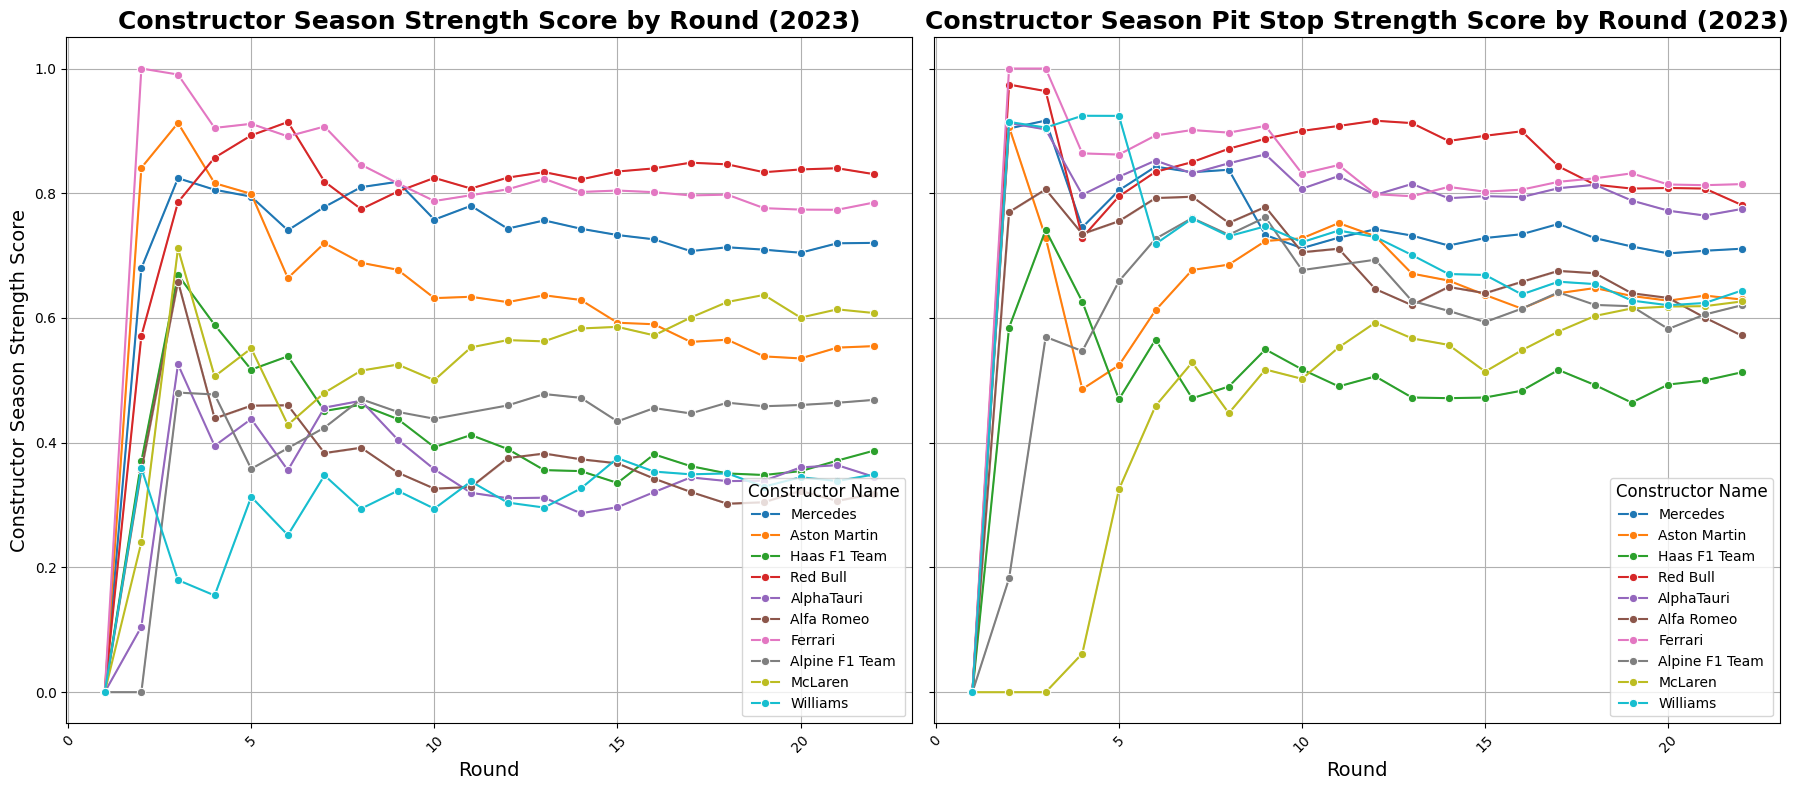

In [70]:
model_data['constructorId_x'] = model_data['constructorId_x'].astype(str)
constructors['constructorId'] = constructors['constructorId'].astype(str)
model_data_with_names = model_data.merge(
    constructors[['constructorId', 'name']],
    left_on='constructorId_x',
    right_on='constructorId',
    how='left'
)

data_2023 = model_data_with_names[model_data_with_names['year'] == 2023]

fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharex=True, sharey=True)
constructor_names = data_2023['name'].unique()
for constructor_name in constructor_names:
    constructor_data = data_2023[data_2023['name'] == constructor_name]
    if not constructor_data.empty:
        sns.lineplot(
            x='round',
            y='constructorSeasonStrengthScore',
            data=constructor_data,
            marker='o',
            label=constructor_name,
            ax=axes[0])

axes[0].set_title('Constructor Season Strength Score by Round (2023)', fontsize=18, fontweight='bold')
axes[0].set_xlabel('Round', fontsize=14)
axes[0].set_ylabel('Constructor Season Strength Score', fontsize=14)
axes[0].grid(True)
axes[0].legend(title='Constructor Name', fontsize=10, title_fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
for constructor_name in constructor_names:
    constructor_data = data_2023[data_2023['name'] == constructor_name]
    if not constructor_data.empty:
        sns.lineplot(
            x='round',
            y='constructorSeasonPitStopStrengthScore',
            data=constructor_data,
            marker='o',
            label=constructor_name,
            ax=axes[1])
axes[1].set_title('Constructor Season Pit Stop Strength Score by Round (2023)', fontsize=18, fontweight='bold')
axes[1].set_xlabel('Round', fontsize=14)
axes[1].set_ylabel('Constructor Season Pit Stop Strength Score', fontsize=14)
axes[1].grid(True)
axes[1].legend(title='Constructor Name', fontsize=10, title_fontsize=12)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### Constructor Season Strength Score
Because of the distribution by team seen before we construction two variables to measure a constructor(teams) strength.  First we make constructor season strength score by round which takes the team's average qualifying time across both of their racers and then normalizing it on a 0-1 distribution with each of the other teams.  The slowest team on average is assinged a score of 0 and the fastest average team is assigned a score of 1.  Becuase teams are continually developing their car over the course of the season, we average continually update this score by averaging throught each round in the season.  We belive this variable captures an individual team's strength.
#### Constructor Pit Stop Strength Score

We use a similar method to capture how good a team is at pit stops. Pit stops can have a major impact on overall race results because drivers commonly pit at similar times, and a half-second difference in the pit stop time can result in a position change.

## 3.2: Pit-Stop Data By Team and by Season

In [71]:
color_palette = 'coolwarm'

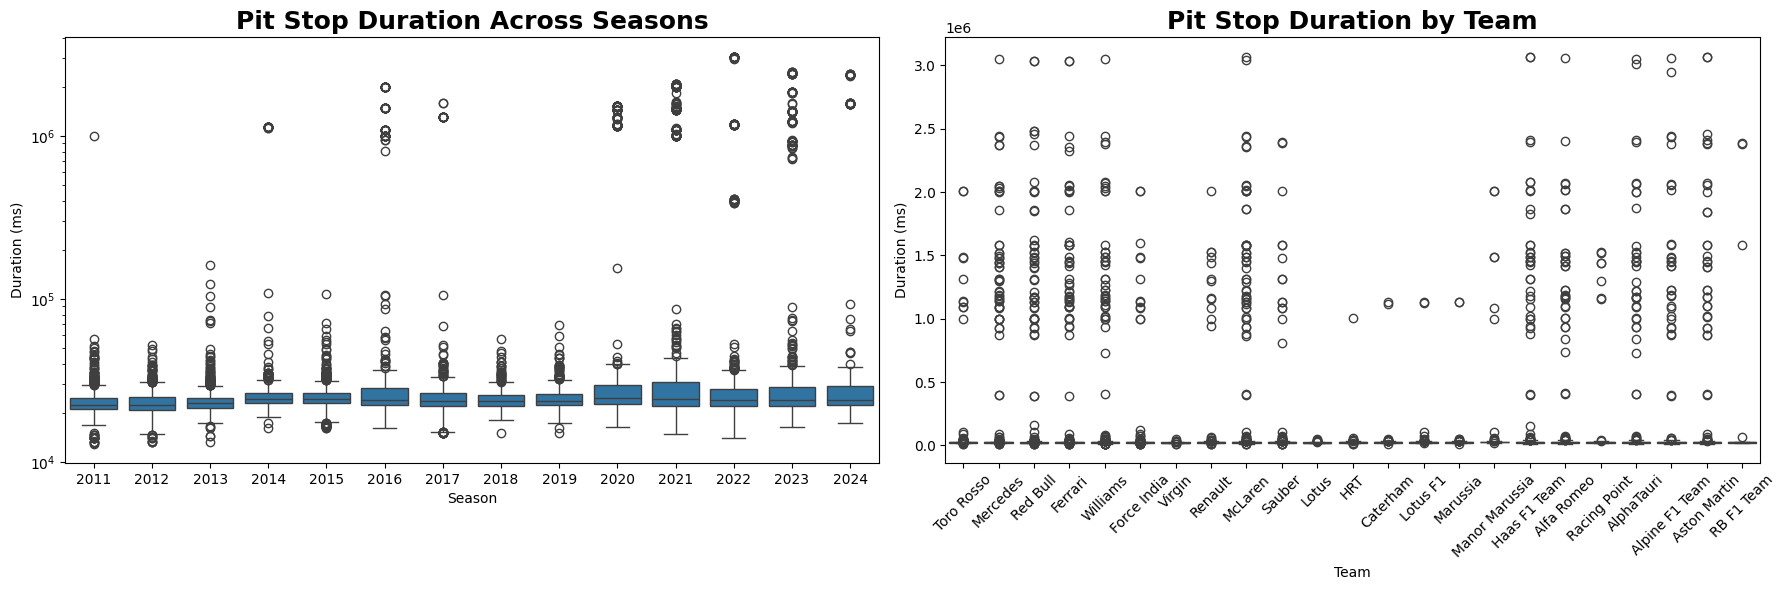

In [72]:
pit_stops_with_seasons = pit_stops.merge(races[['raceId', 'year']], on='raceId')
pit_stops_with_teams = pit_stops_with_seasons.merge(results[['raceId', 'driverId', 'constructorId']], on=['raceId', 'driverId'])

pit_stops_with_teams['constructorId'] = pit_stops_with_teams['constructorId'].astype(int)
constructors['constructorId'] = constructors['constructorId'].astype(int)

pit_stops_with_teams = pit_stops_with_teams.merge(constructors[['constructorId', 'name']], on='constructorId')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Box plot for pit stops across seasons
sns.boxplot(data=pit_stops_with_seasons, x='year', y='milliseconds', ax=axes[0])
axes[0].set_title('Pit Stop Duration Across Seasons', fontsize=18, fontweight='bold')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Duration (ms)')
axes[0].set_yscale('log')

# Box plot for pit stops by team
sns.boxplot(data=pit_stops_with_teams, x='name', y='milliseconds', ax=axes[1])
axes[1].set_title('Pit Stop Duration by Team', fontsize=18, fontweight='bold')
axes[1].set_xlabel('Team')
axes[1].set_ylabel('Duration (ms)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


The plot above describes the spread in pit stop duration across seasons and by team.  The plots show a wide variety by season and a strong number of outliers for certain teams.

## 3.3: Importance of Grid Position on Final Results

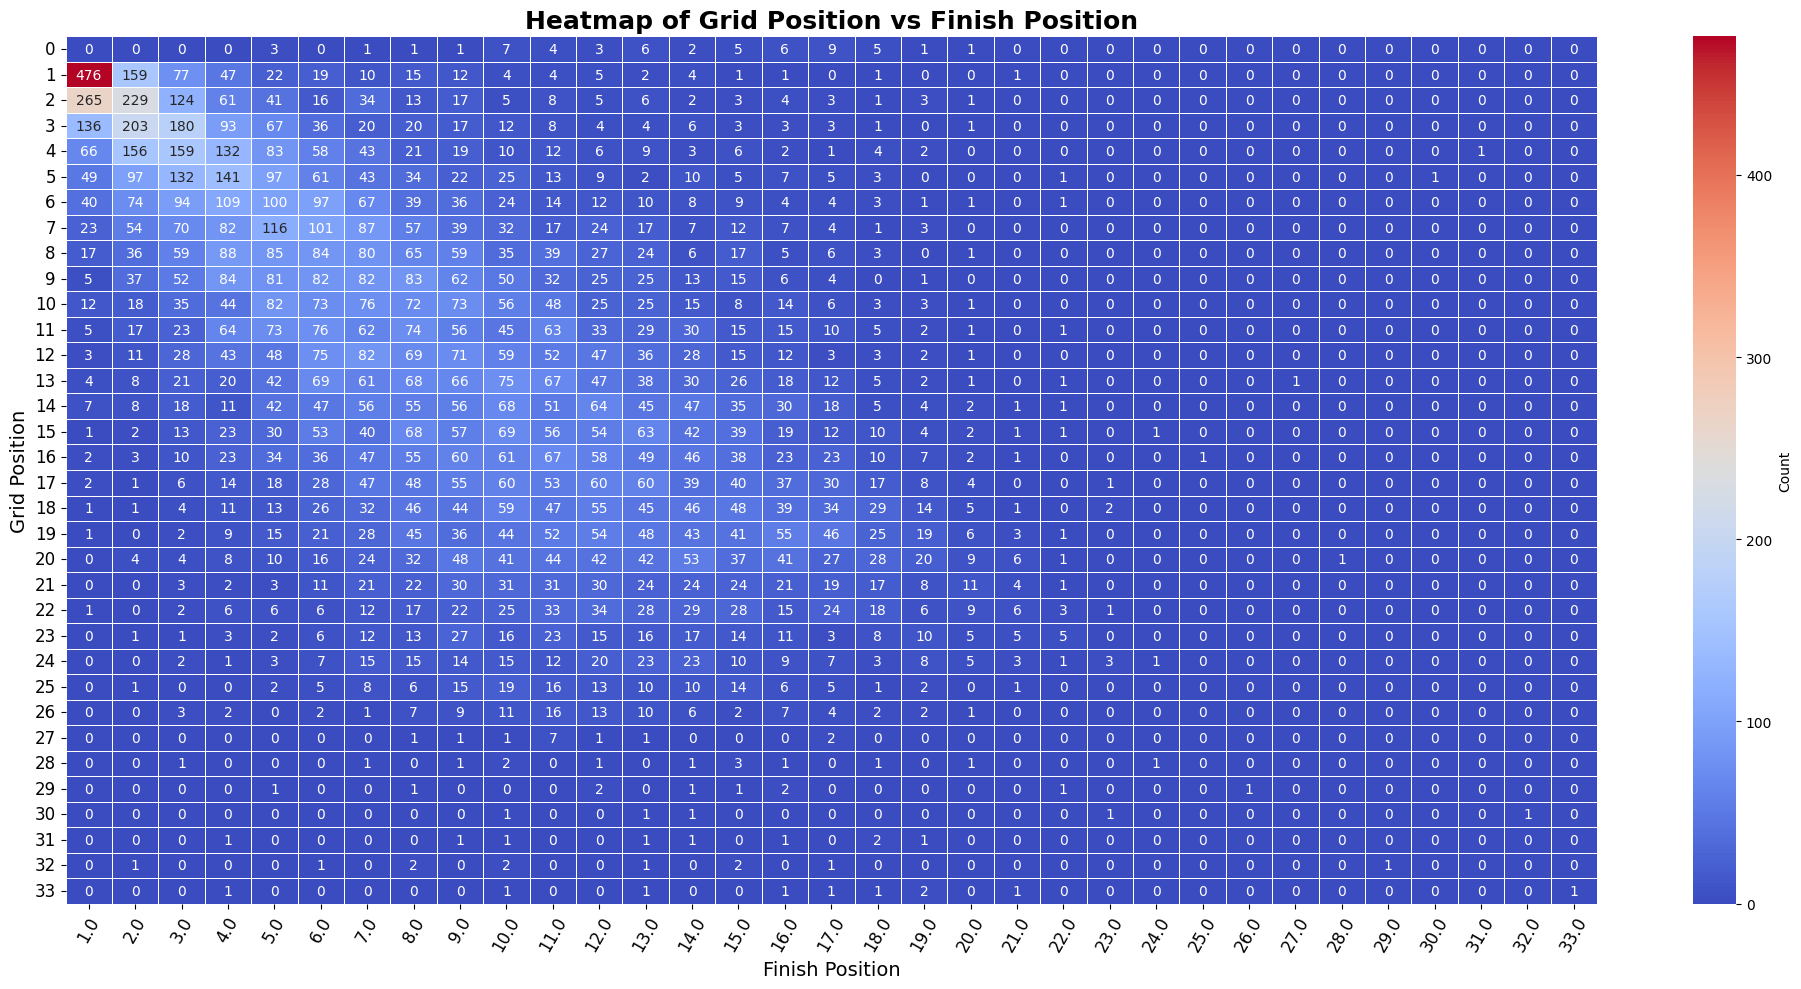

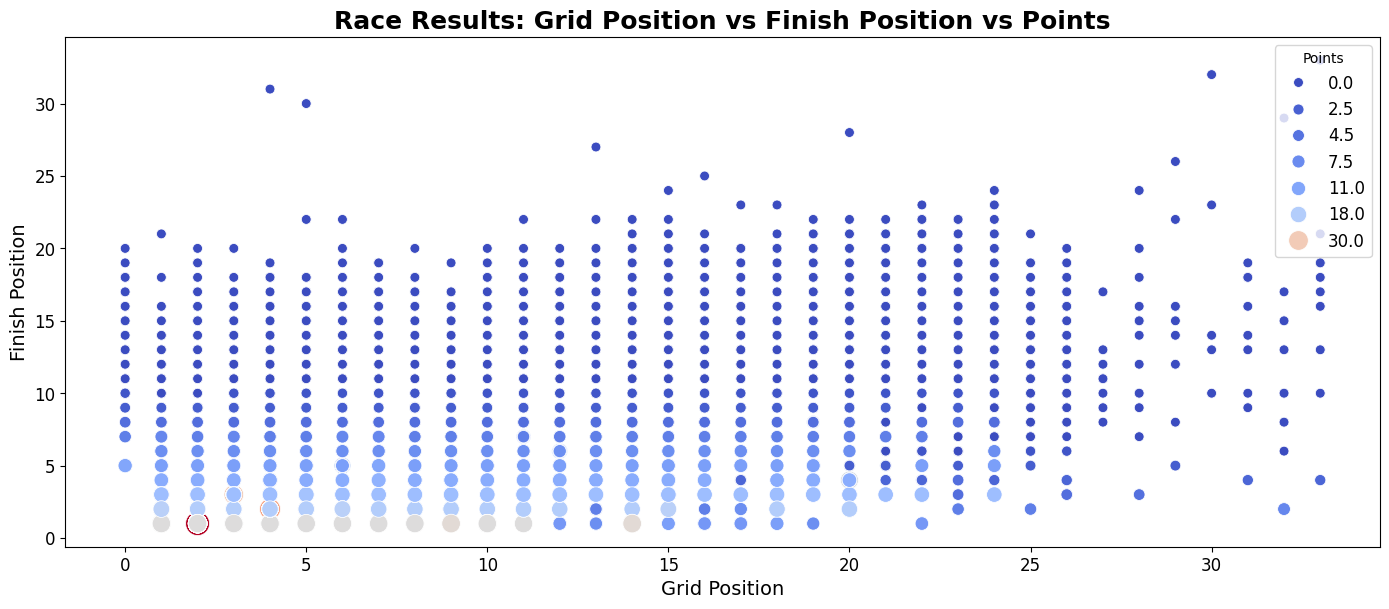

In [73]:
# Heatmap of grid position and finish position
plt.figure(figsize=(20, 10))
grid_vs_finish = results[['grid', 'position']]
grid_vs_finish = grid_vs_finish.groupby(['grid', 'position']).size().reset_index(name='counts')
grid_pivot = grid_vs_finish.pivot(index='grid', columns='position', values='counts').fillna(0)

sns.heatmap(
    grid_pivot,
    cmap=color_palette,
    cbar_kws={'label': 'Count'},
    annot=True,
    fmt='g',
    linewidths=0.5
)
plt.title('Heatmap of Grid Position vs Finish Position', fontsize=18, fontweight='bold')
plt.xlabel('Finish Position', fontsize=14)
plt.ylabel('Grid Position', fontsize=14)
plt.xticks(fontsize=12, rotation=60)
plt.yticks(fontsize=12, rotation=0)
plt.tight_layout()
plt.show()

# Scatter plot for Grid Position vs Finish Position vs Points
plt.figure(figsize=(14, 8))
scatter = sns.scatterplot(x='grid', y='position', size='points', data=results, sizes=(50, 300), hue='points', palette=color_palette, legend='full', marker='o')

plt.title('Race Results: Grid Position vs Finish Position vs Points', fontsize=18, fontweight='bold')
plt.xlabel('Grid Position', fontsize=14)
plt.ylabel('Finish Position', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()


unique_points = sorted(results['points'].unique())
filtered_points = unique_points[::6]
handles, labels = scatter.get_legend_handles_labels()

filtered_handles = [handle for handle, label in zip(handles, labels) if float(label) in filtered_points]
filtered_labels = [label for label in labels if float(label) in filtered_points]

plt.legend(filtered_handles, filtered_labels, title='Points', loc='upper right', fontsize=12)

plt.show()

The heatmap of grid position vs. finish position shows a strong correlation between starting in the first position and finishing in the first position. Additionally, the top 3 grid positions have a strong correlation with staying in that range. Grid positions outside of this range have a slight correlation with finishing in the same position or within 2 places up or down. While grid position is a strong predictor for the 1st bucket, this predictive power is not as strong for buckets outside of this.

The second plot shows how these variables interact with the number of points that are scored.  The number of points by position is not linear(the differnce between points for 1st and second place is greater than the difference between 2nd and 3rd) which is represneted by the size of the circles in the plot.

## 3.4: Points by Constructor

<ipython-input-74-11c7fad6a638>:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_constructor_standings_filtered['name'] = df_constructor_standings_filtered['constructorId'].map(constructor_name_mapping)


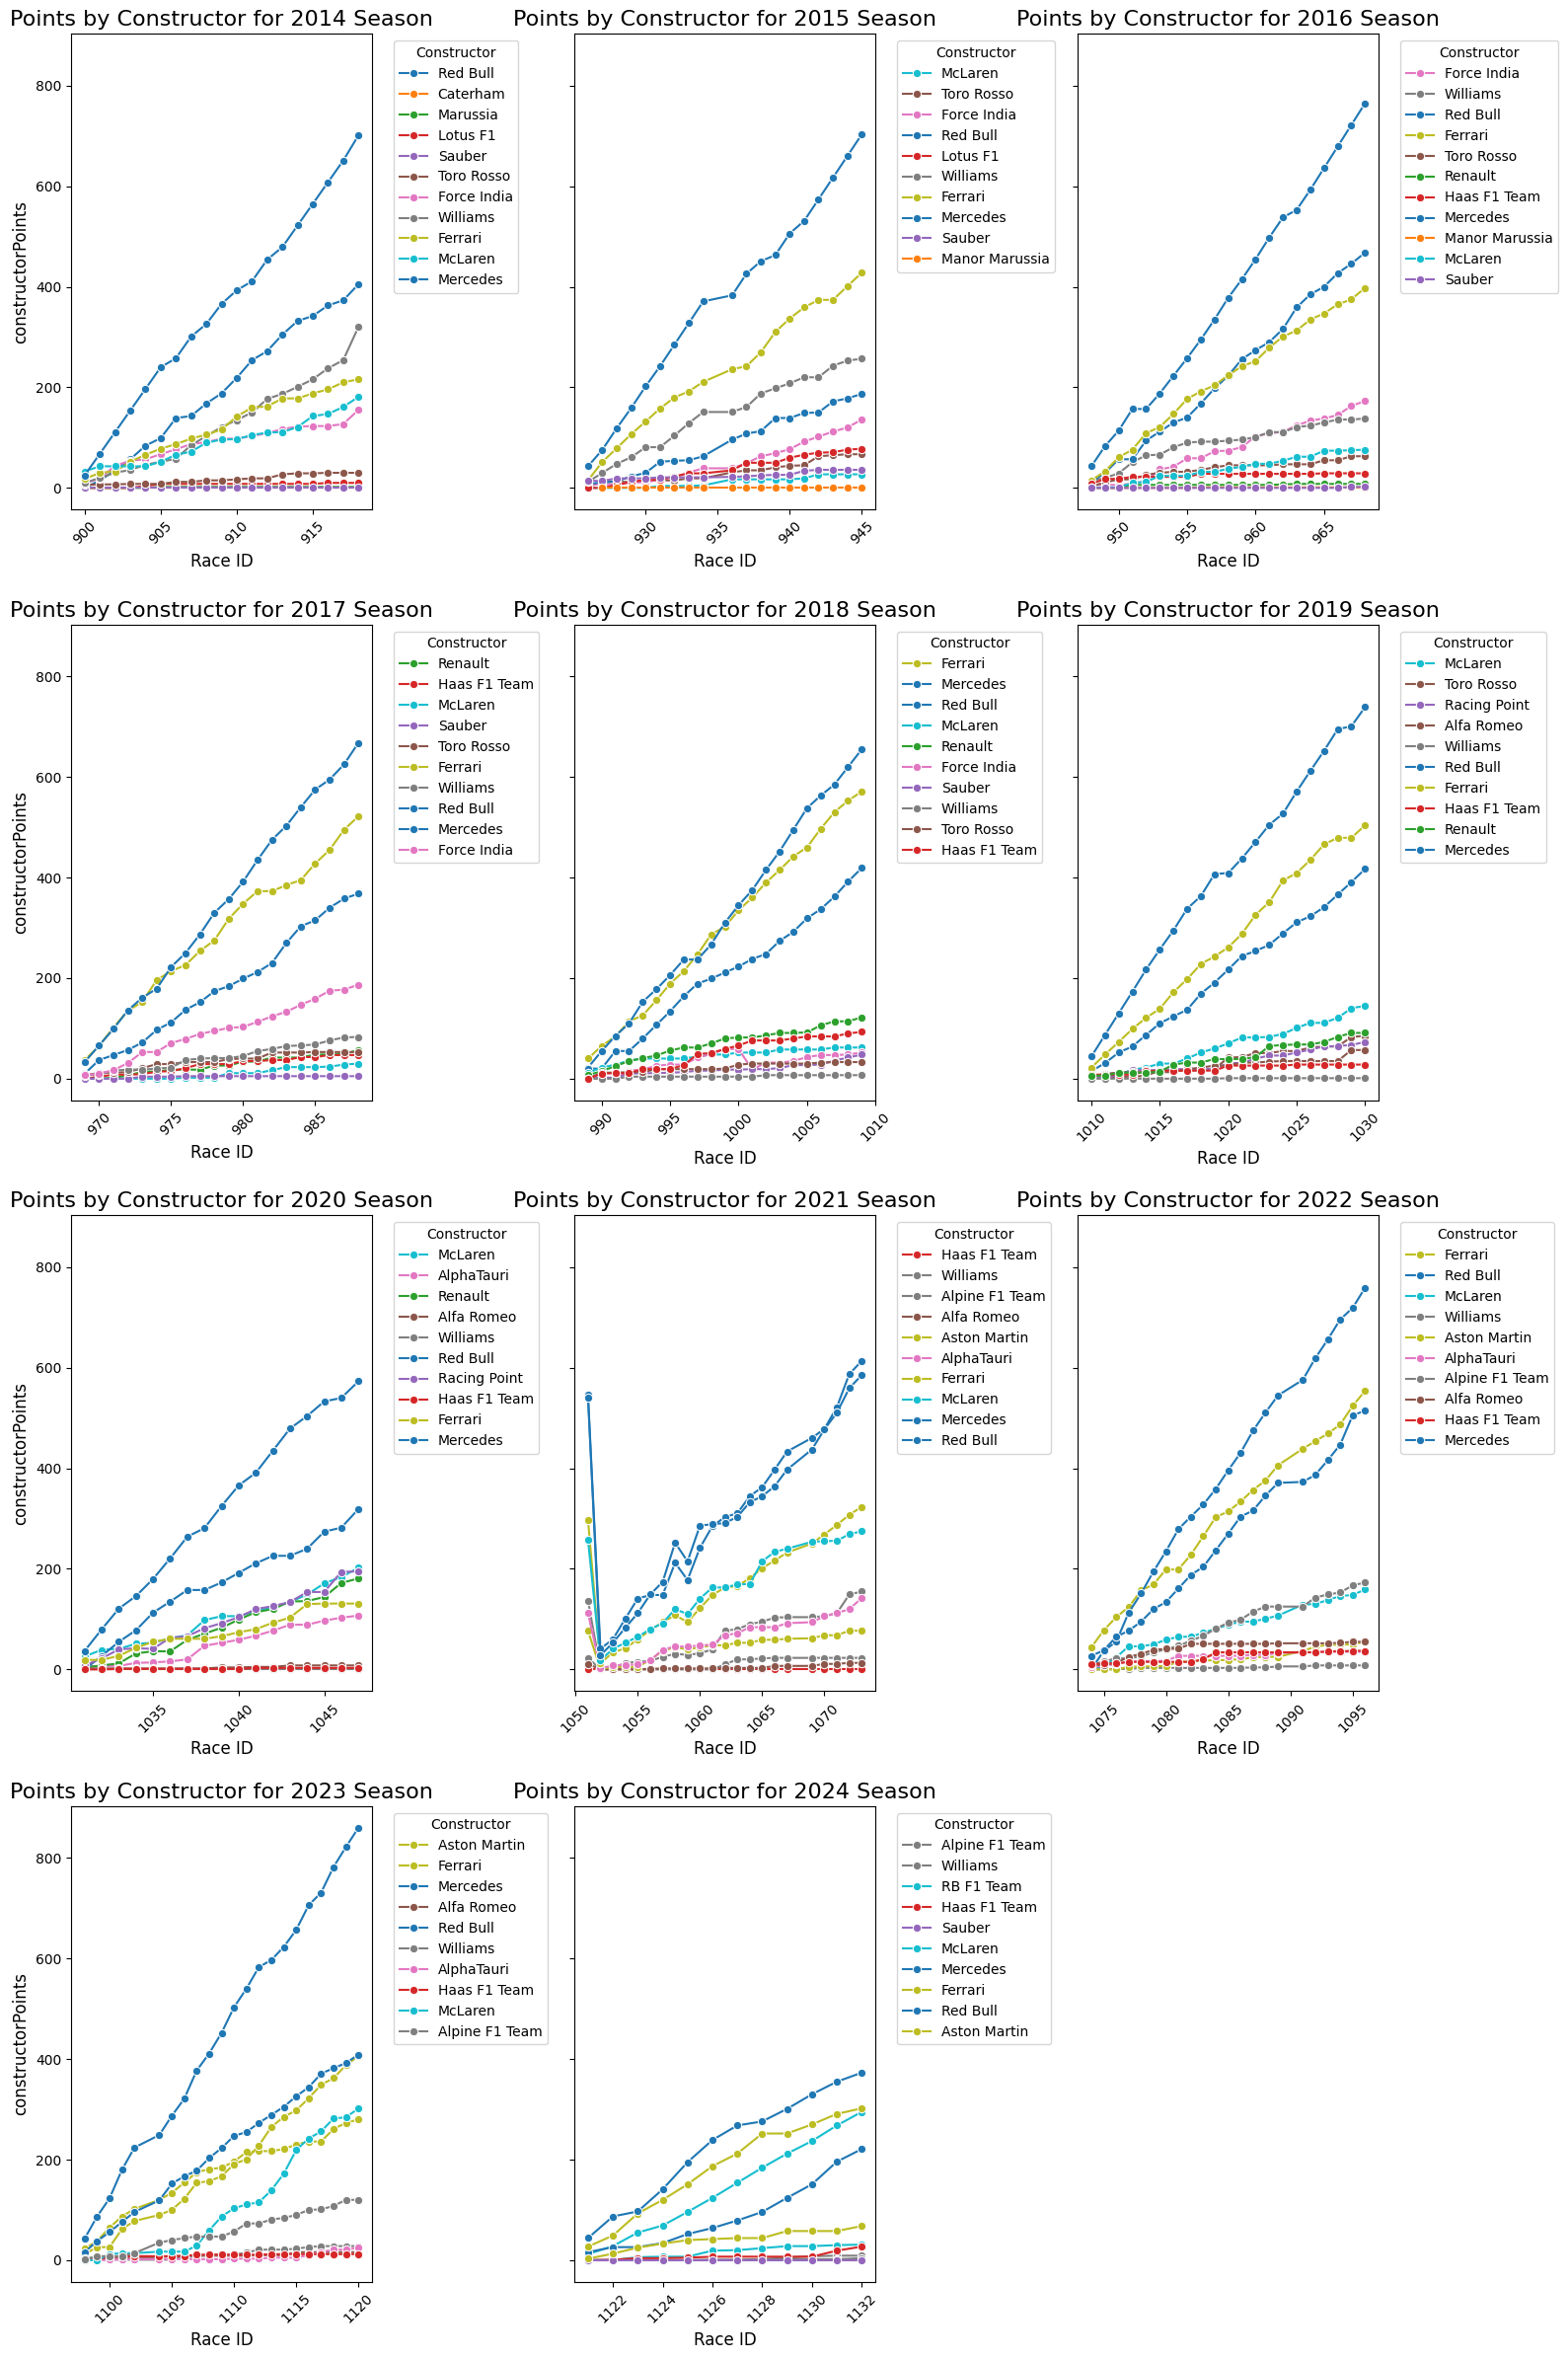

In [74]:
df_races = races[['raceId', 'year', 'name', 'date']]
df_constructor_standings = constructor_standings[['constructorId', 'raceId', 'constructorPoints']]
df_constructors = constructors[['constructorId', 'name']]

# Filter since 14
df_races_filtered = df_races[df_races['year'] >= 2014]

# Filter for raceIds present in df_races_filtered
df_constructor_standings_filtered = df_constructor_standings[
    df_constructor_standings['raceId'].isin(df_races_filtered['raceId'])
]

# Create a dictionary mapping constructorId to constructor name and add name column to mapping!
constructor_name_mapping = df_constructors.set_index('constructorId')['name'].to_dict()
df_constructor_standings_filtered['name'] = df_constructor_standings_filtered['constructorId'].map(constructor_name_mapping)

# Get full race details
df_combined = df_constructor_standings_filtered.merge(
    df_races_filtered[['raceId', 'year', 'date']],
    on='raceId',
    how='left'
)

df_combined = df_combined.sort_values(by='date')
constructors_for_all_years = df_combined['name'].unique()

# Define a consistent color palette
palette = sns.color_palette("tab10", len(constructors_for_all_years))
color_map = {constructor: palette[idx] for idx, constructor in enumerate(constructors_for_all_years)}

years = df_combined['year'].unique()
n_years = len(years)
ncols = 3
nrows = (n_years + ncols - 1) // ncols

# Plot
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 6 * nrows), sharey=True)
axes = axes.flatten()

for i, year in enumerate(sorted(years)):
    # Filter data for the current year
    df_year = df_combined[df_combined['year'] == year]

    # Create subplot for each year
    sns.lineplot(
        ax=axes[i],
        data=df_year,
        x='raceId',
        y='constructorPoints',
        hue='name',
        palette=color_map,
        marker='o'
    )

    axes[i].set_title(f'Points by Constructor for {year} Season', fontsize=16)
    axes[i].set_xlabel('Race ID', fontsize=12)
    axes[i].set_ylabel('constructorPoints', fontsize=12)
    axes[i].legend(title='Constructor', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    axes[i].tick_params(axis='x', rotation=45)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

We show points by constructor by season to more clearly illustrate how a team can dominate a particular season. In 2023, we see clear distinctions for the top teams, while the lowest-scoring teams do not show much of a difference. Because of this small difference at lower levels, the constructors’ score season strength variable we constructed can shed light on the difference in car quality at lower levels. Because drivers in the bottom half of the grid earn 0 points, it is possible for multiple teams to end the season with 0 points.

## 3.5: Elo Scores over Time

<ipython-input-75-599c0e4635cd>:12: UserWarning: 
The palette list has fewer values (20) than needed (23) and will cycle, which may produce an uninterpretable plot.
  sns.lineplot(data=plot_data, x='raceId', y='elo_score', hue='surname', marker='o', palette=palette)


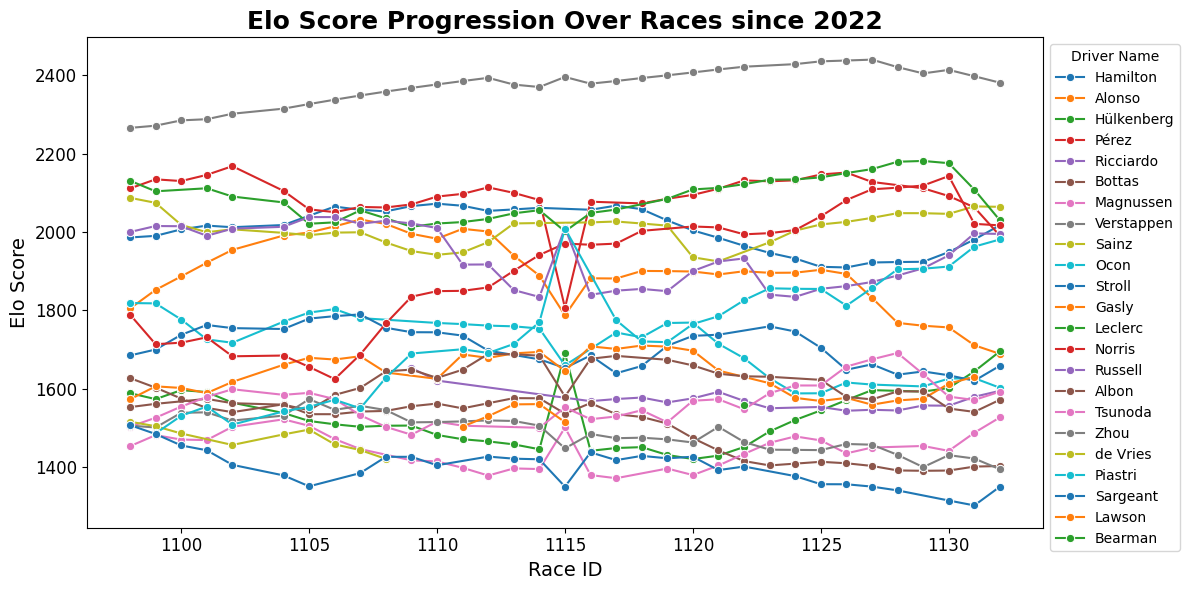

In [75]:
# Merge the drivers data with model_data to get the surname for each driverId
plot_data_2024 = model_data[model_data['year'] > 2022]
plot_data_2024 = plot_data_2024.merge(drivers[['driverId', 'surname']], on='driverId', how='left')

# Plot the Elo score over races for 2024
plt.figure(figsize=(12, 6))

# Filter the relevant columns for plotting
plot_data = plot_data_2024[['raceId', 'surname', 'elo_score']]

# Line plot for each driver
sns.lineplot(data=plot_data, x='raceId', y='elo_score', hue='surname', marker='o', palette=palette)

# Customize the plot
plt.title('Elo Score Progression Over Races since 2022', fontsize=18, fontweight='bold')
plt.xlabel('Race ID', fontsize=14)
plt.ylabel('Elo Score', fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(title='Driver Name', bbox_to_anchor=(1, 1), loc='upper left')
plt.tight_layout()
plt.show()


Our Elo score calculation is a method to provide insight into each driver’s skill level. Elo scores are a chess-style ranking system that are continuously updated based on a driver’s placement in relation to other drivers’ performance. Each driver is initially assigned a score of 1500. If a driver with a 2000 Elo score places below a driver with a 1400 Elo score, they will be penalized and rewarded by a greater amount than if a 1600 Elo score driver loses to a 1500 Elo score driver. The progression of the Elo score plot above provides insight into the strength distribution of F1 drivers.

## 3.6 Finishing Quartile Distribution

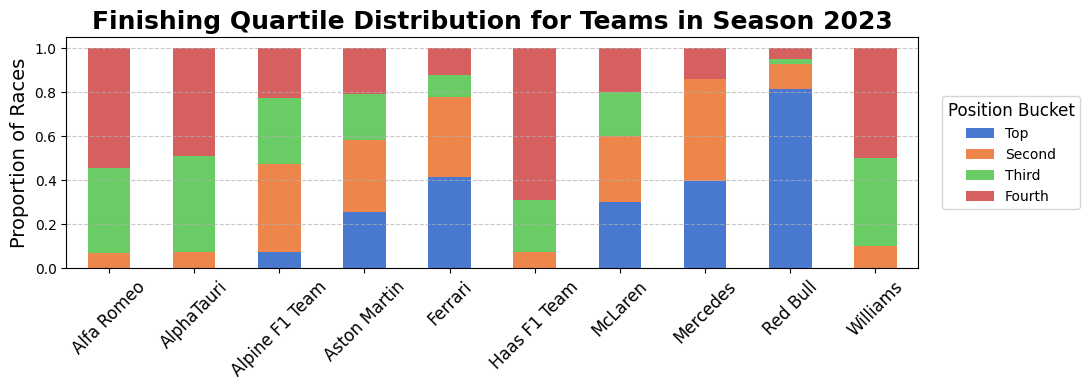

In [76]:
def visualize_team_position_buckets_with_names_stacked(model_data, constructors, season):
    """
    Visualizes the distribution of position buckets for each team over a season with constructor names using a stacked bar chart.

    :param model_data: DataFrame containing 'constructorId', 'position_bucket', and 'year'.
    :param constructors: DataFrame containing constructor IDs and names.
    :param season: The year/season to visualize.
    """
    # Ensure constructor IDs are strings for consistent merging
    model_data['constructorId'] = model_data['constructorId_x'].astype(str)
    constructors['constructorId'] = constructors['constructorId'].astype(str)

    # Merge constructor names into the model data
    model_data_with_names = model_data.merge(
        constructors[['constructorId', 'name']],
        left_on='constructorId',
        right_on='constructorId',
        how='left'
    )

    # Filter data for the specified season
    season_data = model_data_with_names[model_data_with_names['year'] == season]

    # Count position buckets by team
    team_buckets = season_data.groupby(['name', 'position_bucket']).size().unstack(fill_value=0)

    # Normalize counts to show percentages
    team_buckets_percentage = team_buckets.div(team_buckets.sum(axis=1), axis=0)

    # Create a stacked bar chart
    bucket_labels = {0: "Top", 1: "Second", 2: "Third", 3: "Fourth"}
    team_buckets_percentage.rename(columns=bucket_labels, inplace=True)
    colors = sns.color_palette("muted", n_colors=4)

    # Plot
    team_buckets_percentage.plot(
        kind='bar',
        stacked=True,
        figsize=(11, 4),
        color=colors,
        edgecolor='none'
    )

    # Annotate the plot
    plt.title(f"Finishing Quartile Distribution for Teams in Season {season}", fontsize=18, fontweight='bold')
    plt.ylabel("Proportion of Races", fontsize=14)
    plt.xlabel("")  # Remove x-axis label
    plt.xticks(rotation=45, fontsize=12)
    plt.legend(
        title="Position Bucket",
        loc='center left',
        bbox_to_anchor=(1.02, 0.5),
        fontsize=10,
        title_fontsize=12
    )
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    # Show the plot
    plt.tight_layout()
    plt.show()

# Example usage
visualize_team_position_buckets_with_names_stacked(model_data, constructors, season=2023)  # Replace 2024 with the desired season

The above displays teams finishing distributions for the 2023 season.  Naturally, different teams are more dominant than others over the span of any given season.  This insight into how teams vary widly in preformance inform our decision to construct variables for team strength. This visualization provides a baseline into what it is we are trying to predict throughout the modelling process.


# SECTION 4: Models

## 4.1: Modeling Overview

### 4.11: Train-Val-Test Split

In [77]:
# Split model_data into training, validation, and test sets based on the year
train_data = model_data[model_data['year'] <= 2022]  # Data up to 2022 for training
val_data = model_data[model_data['year'] == 2023]    # Data for 2023 for validation
test_data = model_data[model_data['year'] == 2024]   # Data for 2024 for testing

# Display the shapes of the datasets to confirm the split
print(f"Training Data Shape: {train_data.shape}")
print(f"Validation Data Shape: {val_data.shape}")
print(f"Test Data Shape: {test_data.shape}")

Training Data Shape: (4681, 46)
Validation Data Shape: (417, 46)
Test Data Shape: (228, 46)


### 4.12: Defining a Results Dictionary

In [78]:
def update_model_results(model_results, model_number, model_name, train_accuracy, val_accuracy, test_accuracy=None):
    """
    Update the model results dictionary with new model details.

    Parameters:
    - model_results (dict): The dictionary to update with model results.
    - model_number (str): Unique identifier for the model (e.g., '4.3.2').
    - model_name (str): Name or description of the model.
    - train_accuracy (float): Training accuracy of the model.
    - val_accuracy (float): Validation accuracy of the model.
    - test_accuracy (float, optional): Test accuracy of the model. Default is None.

    Returns:
    - dict: Updated model results dictionary.
    """
    # Create an entry for the current model
    model_entry = {
        "Model Name": model_name,
        "Train Accuracy": train_accuracy,
        "Validation Accuracy": val_accuracy
    }

    # Add test accuracy if provided
    if test_accuracy is not None:
        model_entry["Test Accuracy"] = test_accuracy

    # Update the dictionary
    model_results[model_number] = model_entry
    return model_results

model_results = {}

## 4.2: Majority Classification

### 4.2.1 Motivation and Description

We employed Majority classification as a baseline model; it predicts the most frequently occurring class in the training dataset for all instances.

Mathematically, the majority class is determined by finding the mode of the target variable in the training dataset:

$$
\text{Majority Class} = \text{argmax}_c \, \text{Count}(c), \, \forall c \in \text{Classes}
$$

Then, assign all predictions to this class:

$$
\hat{y}_i = \text{Majority Class}, \, \forall i \in \text{Instances}
$$

### 4.2.2: Code

In [79]:
# Define the target variable
target = 'position_bucket'

# Find the majority class in the training set
majority_class = train_data[target].mode()[0]  # Most frequent class

# Predict the majority class for all instances in the validation and test sets
y_val_majority_pred = [majority_class] * len(val_data)
y_test_majority_pred = [majority_class] * len(test_data)

# Extract the actual target values from the validation and test sets
y_val = val_data[target]
y_test = test_data[target]

# Evaluate the performance of the majority class model
val_accuracy = accuracy_score(y_val, y_val_majority_pred)
test_accuracy = accuracy_score(y_test, y_test_majority_pred)

# Print results
print(f"Majority Class: {majority_class}")
print(f"Validation Accuracy (Majority Class Model): {val_accuracy:.4f}")
print(f"Test Accuracy (Majority Class Model): {test_accuracy:.4f}")

Majority Class: 3
Validation Accuracy (Majority Class Model): 0.3165
Test Accuracy (Majority Class Model): 0.2895


In [80]:
# Save the results for the Majority Classification model
model_results = update_model_results(
    model_results=model_results,
    model_number="4.2.2",
    model_name="Majority Classification",
    train_accuracy=None,
    val_accuracy=val_accuracy,
    test_accuracy=test_accuracy
)

# Print the updated model results
print(model_results)

{'4.2.2': {'Model Name': 'Majority Classification', 'Train Accuracy': None, 'Validation Accuracy': 0.31654676258992803, 'Test Accuracy': 0.2894736842105263}}


### 4.2.3: Results

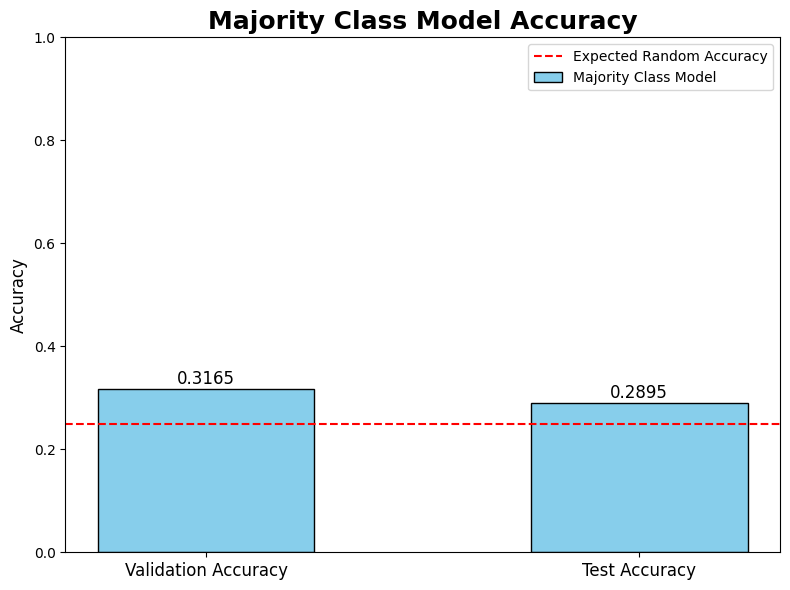

In [81]:
# Prepare data for visualization
metrics = ['Validation Accuracy', 'Test Accuracy']
scores = [val_accuracy, test_accuracy]
expected_random_accuracy = 1 / train_data[target].nunique()  # Assuming the number of unique classes

# Visualization
plt.figure(figsize=(8, 6))
bar_width = 0.5
x = np.arange(len(metrics))

# Plot actual accuracies
plt.bar(x, scores, bar_width, label='Majority Class Model', color='skyblue', edgecolor='black')

# Plot expected random accuracy as a horizontal line
plt.axhline(y=expected_random_accuracy, color='red', linestyle='--', label='Expected Random Accuracy')

# Annotate bars
for i, score in enumerate(scores):
    plt.text(x[i], score + 0.01, f"{score:.4f}", ha='center', fontsize=12, color='black')

# Add labels, title, and legend
plt.xticks(x, metrics, fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim([0,1])
plt.title('Majority Class Model Accuracy', fontsize=18, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()


We see that our majority classification model has a 29% test accuracy and a 32% validation accuracy, both above the 25% random classification threshold. This implies some level of class imbalance.

## 4.3: Logistic Regression

### 4.3.1 Motivation and Description of Logistic Regression

We next employ multi-class Logistic regression (OneVsRest Classification).OvR creates separate binary classifier for each class which then distinguishes each specific class from the others. During prediction, the probabilities of belonging to each class are calculated, and the class with the highest probability is selected as the predicted label.

Mathematically, OvR regression is calculated as follows, starting with the probability of an instance belonging to class $k$ is given by:

$$
P(y = k \mid X) = \frac{1}{1 + e^{-(\beta_{k0} + \beta_{k1} X_1 + \beta_{k2} X_2 + \dots + \beta_{kp} X_p)}}
$$

Where:

$P(y = k \mid X)$ is the probability of the target variable $y$ belonging to class $k$ given the feature set $X$.

$\beta_{k0}, \beta_{k1}, \dots, \beta_{kp}$ are the coefficients learned for class $k$.

$X_1, X_2, \dots, X_p$ are the features used for prediction.

The predicted class $\hat{y}$ is determined as the class with the highest probability:

$$
\hat{y} = \underset{k}{\text{argmax }} P(y = k \mid X)
$$

Where:

$\underset{k}{\text{argmax }}$ is the argmax function, which returns the class $k$ with the highest probability.

$k \in \{0, 1, \dots, K-1\}$, where $K$ is the total number of classes.

### 4.3.2: Code

In [82]:
features = [
    'grid', 'rank', 'laps',
    'averagePitStopTime', 'averageTeamPitStopTimePerRace',
    'standarizedPitStopTeamScore', 'constructorSeasonPitStopStrengthScore', 'lastYearStrength', 'elo_score'
]
target = 'position_bucket'

# Split data
X_train = train_data[features]
y_train = train_data[target]
X_val = val_data[features]
y_val = val_data[target]
X_test = test_data[features]
y_test = test_data[target]

# Create a pipeline
pipeline = make_pipeline(
    StandardScaler(),
    LogisticRegression(penalty='l2', max_iter=100000, random_state=42)
)

# Fit the model
pipeline.fit(X_train, y_train)

# Evaluate the model
print("Training Accuracy:", pipeline.score(X_train, y_train))
print("Validation Accuracy:", pipeline.score(X_val, y_val))
print("Test Accuracy:", pipeline.score(X_test, y_test))

Training Accuracy: 0.6267891476180303
Validation Accuracy: 0.580335731414868
Test Accuracy: 0.6096491228070176


In [83]:
# Save the results for the Logistic Classifier model
model_results = update_model_results(
    model_results=model_results,
    model_number="4.3.2",
    model_name="Logistic Classifier",
    train_accuracy=pipeline.score(X_train, y_train),
    val_accuracy=pipeline.score(X_val, y_val),
    test_accuracy=pipeline.score(X_test, y_test)
)

# Print the updated model results
print(model_results)

{'4.2.2': {'Model Name': 'Majority Classification', 'Train Accuracy': None, 'Validation Accuracy': 0.31654676258992803, 'Test Accuracy': 0.2894736842105263}, '4.3.2': {'Model Name': 'Logistic Classifier', 'Train Accuracy': 0.6267891476180303, 'Validation Accuracy': 0.580335731414868, 'Test Accuracy': 0.6096491228070176}}


### 4.3.3: Results

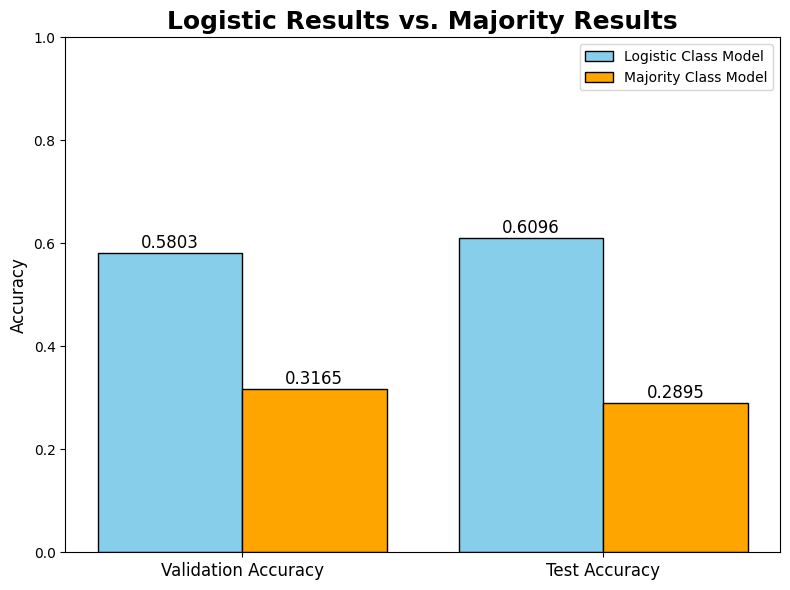

In [84]:
# Prepare data for visualization
metrics = ['Validation Accuracy', 'Test Accuracy']
scores = [pipeline.score(X_val, y_val), pipeline.score(X_test, y_test)]  # Logistic Class Model scores
majority_scores = [model_results["4.2.2"]["Validation Accuracy"], model_results["4.2.2"]["Test Accuracy"]]
bar_width = 0.4  # Reduce width slightly for better spacing
x = np.arange(len(metrics))  # Base x positions for the metrics

plt.figure(figsize=(8, 6))

# Plot Logistic Class Model
plt.bar(x - bar_width / 2, scores, bar_width, label='Logistic Class Model', color='skyblue', edgecolor='black')

# Plot Majority Class Model
plt.bar(x + bar_width / 2, majority_scores, bar_width, label='Majority Class Model', color='orange', edgecolor='black')

# Annotate bars for Logistic Class Model
for i, score in enumerate(scores):
    plt.text(x[i] - bar_width / 2, score + 0.01, f"{score:.4f}", ha='center', fontsize=12, color='black')

# Annotate bars for Majority Class Model
for i, score in enumerate(majority_scores):
    plt.text(x[i] + bar_width / 2, score + 0.01, f"{score:.4f}", ha='center', fontsize=12, color='black')

# Add labels, title, and legend
plt.xticks(x, metrics, fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim([0,1])
plt.title('Logistic Results vs. Majority Results', fontsize=18, fontweight='bold')
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

Above we see the comparision between the Logistic Regression Model and the Majority Classification model, we can see that our Logistic Regression Model is a significant improvement on our baseline model, though there is still a lot of improvement to be made before we achieve our 70% goal threshold.

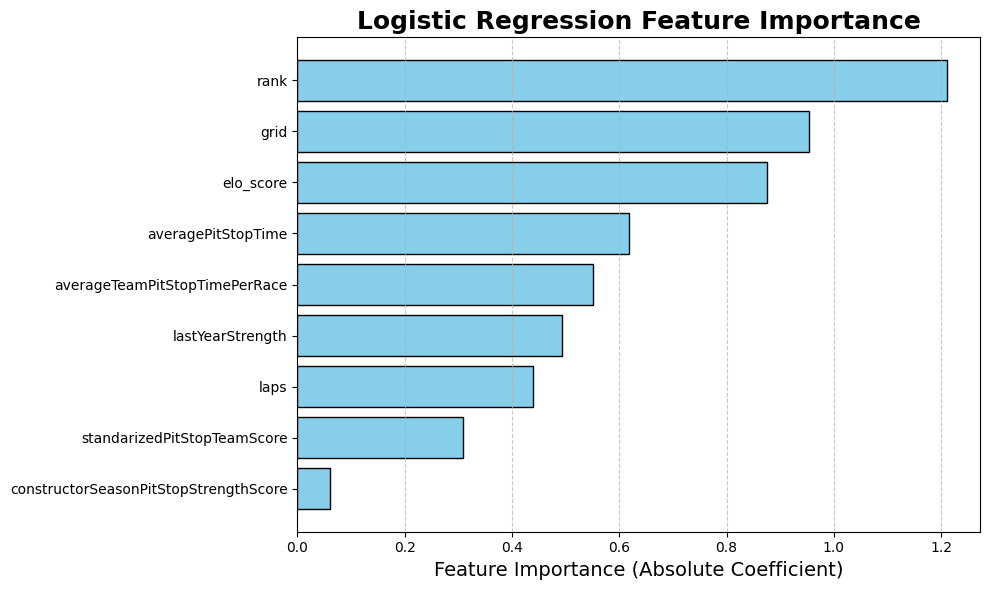

In [85]:
# Extract the logistic regression model from the pipeline
logistic_model = pipeline.named_steps['logisticregression']

# Get feature names and coefficients
feature_names = features
coefficients = logistic_model.coef_[0]

# Create a DataFrame for feature importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Importance': np.abs(coefficients)
})

# Sort features by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue', edgecolor='black')
plt.xlabel('Feature Importance (Absolute Coefficient)', fontsize=14)
plt.title('Logistic Regression Feature Importance', fontsize=18, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

The logistic regression model finds that rank, grid and elo_score are the most important features for predicting the position bucket of the drivers. This implies that 1) our variable construction does provide addtiional insights and improvements, a strong sign and endorsement of our use of elo and 2) that the starting position of a racer alongside their historical performance plays a large role in determining their current success.

## 4.4: Bagging

### 4.4.1: Motivation and Description

We next employ Bagging, an ensemble learning method focused on reducing variance. In our case, we employ Bagging on decision tree classifiers, which generates multiple decision tree models by resampling the training data with replacement. Each decision tree is trained on a bootstrapped sample of the data and the final prediction is made using majority voting across the ensemble.

In our case, we proceeded as follows:
$ \text{Tree depth: 12 (to allow expressive splits while limiting overfitting).} $  
$ \text{Number of trees: 55 (for sufficient ensemble diversity).} $

1. Generate $n_\text{trees}$ bootstrapped samples from the training dataset.  
2. Train a decision tree classifier on each bootstrapped sample.  
3. Aggregate predictions from all trees using majority voting.  
4. Evaluate accuracy on the validation dataset.  

For a dataset $\{(x_i, y_i)\}_{i=1}^n$:  
1. Generate $B$ bootstrapped samples: $\{(x_i^b, y_i^b)\}$ for $b=1, \dots, B$.  
2. Train a decision tree $f_b(x)$ on each bootstrapped sample.  
3. Combine predictions using majority voting for classification:  
$$
\hat{y} = \underset{y}{\text{argmax }} \sum_{b=1}^B \mathbb{I}(f_b(x) = y)
$$
where $\mathbb{I}(\cdot)$ is the indicator function.

We see Bagging as robust intermediate step in our model development pipeline, offering improvement over our baseline models.

### 4.4.2: Code

In [86]:
#Bagging function provided in HW6
def bagger(
    n_trees: int,
    tree_depth: int,
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_val: np.ndarray,
    random_seed: int = 0,
) -> (pd.DataFrame, pd.DataFrame, list):
    """Generate boostrapped DecisionTreeClassifier predictions

    Function fits bootstrapped DecisionTreeClassifier models
    and returns training and test predictions for each of those
    bootstrapped models, along with the fitted model objects as
    described in Question 2.2 question text.

    :param n_trees: int, number of bootstrapped decision trees
    :param tree_depth: int, maximum tree depth
    :param X_train: np.ndarray, training X observations
    :param y_train: np.ndarray, training y observations
    :param X_val: np.ndarray, validation X observations
    :param random_seed: int, random seed used to set np.random.seed
                        to ensure replicable results (default=0)

    :returns: (pd.DataFrame, pd.DataFrame, list), tuple containing 3
              objects, (1) bagging_train_df dataframe
              as described in Q2.2 question text, (2) bagging_test_df
              dataframe as described in Q2.2, and (3) bagging_models_list
              containing every trained DecisionTreeClassifier model
              object (i.e. estimator), one estimator for each bootstrap
              (you will need this list later in Q3.2)
    """

    # set random seed for replicable results
    np.random.seed(random_seed)

    # instantiate arrays and list for storing results
    bagging_train = np.zeros((X_train.shape[0], n_trees)).astype(int)
    bagging_val = np.zeros((X_val.shape[0], n_trees)).astype(int)

    bagging_models_list = []

    # perform n bootstraps
    for i in range(n_trees):
        # generate bootstrapped model
        bootstrapped_X, bootstrapped_y = resample(X_train, y_train)
        fitted_model = DecisionTreeClassifier(
            max_depth=tree_depth,
            random_state=0
        ).fit(bootstrapped_X, bootstrapped_y)
        bagging_models_list.append(fitted_model)

        # predict on full training and test sets and store
        # results to arrays
        bagging_train[:,i] = fitted_model.predict(X_train)
        bagging_val[:,i] = fitted_model.predict(X_val)

    # convert arrays to pandas dataframes as required
    bagging_train_df = pd.DataFrame(
        bagging_train[:, :],
        columns=[f"model{x}" for x in range(n_trees)],
    )
    bagging_val_df = pd.DataFrame(
        bagging_val[:, :],
        columns=[f"model{x}" for x in range(n_trees)],
    )

    return bagging_train_df, bagging_val_df, bagging_models_list



In [87]:
features = [
    'grid', 'lastYearStrength', 'racerMomentum', 'position_x',
    'driverSpreadRace', 'driverSpreadSeason', 'standardTeamCarScoreByRace',
    'averagePitStopTime', 'position_change', 'constructorSeasonPitStopStrengthScore',
    'standarizedPitStopTeamScore', 'laps','elo_score'
]
target = 'position_bucket'

# Split data
X_train = train_data[features]
y_train = train_data[target]
X_val = val_data[features]
y_val = val_data[target]
X_test = test_data[features]
y_test = test_data[target]

#Set depth of trees to 12 (large in order to be expressive, since overfitting will not be an issue)
tree_depth = 12

#Set n_trees to 55
n_trees = 55

#Use bagging function to get train and validation df
bagging_train_df, bagging_val_df, bagging_models_list = bagger(
    n_trees=n_trees,
    tree_depth=tree_depth,
    X_train=X_train,
    y_train=y_train,
    X_val=X_val,
    random_seed=0
)

# Mode voting for training and validation predictions
bagging_train_preds = mode(bagging_train_df, axis=1)[0].flatten()
bagging_val_preds = mode(bagging_val_df, axis=1)[0].flatten()

# Compute accuracy for train and validation sets
bagging_accuracy_train = (bagging_train_preds == y_train).mean()
bagging_accuracy_val = (bagging_val_preds == y_val).mean()

print("Bagging Train Accuracy:", bagging_accuracy_train)
print("Bagging Validation Accuracy:", bagging_accuracy_val)


Bagging Train Accuracy: 0.8886989959410383
Bagging Validation Accuracy: 0.5683453237410072


In [88]:
# Use the running_predictions function to calculate test predictions
bagging_test_df = pd.DataFrame([model.predict(X_test) for model in bagging_models_list]).T
bagging_test_preds = mode(bagging_test_df, axis=1)[0].flatten()
bagging_test_accuracy = (bagging_test_preds == y_test).mean()
# Save results for the Bagging model
model_results = update_model_results(
    model_results=model_results,
    model_number="4.4.2",
    model_name="Bagging",
    train_accuracy=bagging_accuracy_train,
    val_accuracy=bagging_accuracy_val,
    test_accuracy=bagging_test_accuracy
)

# Print the updated model results
print("\nUpdated Model Results:")
print(model_results)



Updated Model Results:
{'4.2.2': {'Model Name': 'Majority Classification', 'Train Accuracy': None, 'Validation Accuracy': 0.31654676258992803, 'Test Accuracy': 0.2894736842105263}, '4.3.2': {'Model Name': 'Logistic Classifier', 'Train Accuracy': 0.6267891476180303, 'Validation Accuracy': 0.580335731414868, 'Test Accuracy': 0.6096491228070176}, '4.4.2': {'Model Name': 'Bagging', 'Train Accuracy': 0.8886989959410383, 'Validation Accuracy': 0.5683453237410072, 'Test Accuracy': 0.6754385964912281}}


### 4.4.3: Results

In [89]:
#running_predictions function from HW6 (updated for 4-class problem)
def running_predictions(
    bagger_results_df: pd.DataFrame,
    targets: np.ndarray,
) -> pd.Series:
    """Generates running accuracy of intermediate bootstraps when bagging

    Generates a series of accuracy scores calculated using the
    running predictions of each additional bootstrapped model
    generated using the `bagger` function. For example,
    the first accuracy in the series represents the predictive
    accuracy of just the first bootstrapped model. The second accuracy
    reflects the bagged accuracy of the first 2 bootstrapped models. The
    j-th accuracy reflects the bagged accuracy of the first j
    bootstrapped models.

    :param bagger_results_df: pd.DataFrame, a bagging results dataframe
                              (either train or test) output from the
                              `bagger` function
    :param targets: np.ndarray, 1-dimensional array of true class labels
                    for either train or test observations (i.e y_train or
                    y_test, whichever corresponds to the inputted
                    bagger_results_df)
    :returns: pd.Series, a series of values showing the accuracy of
              using the initial j trees to predict the targets for each
              value of j bootstrapped models
    """
    # verify that input data objects meet the requirements specified
    # in the docstring
    assert type(bagger_results_df)==pd.core.frame.DataFrame, (
        "bagger_results_df input must be a pd.DataFrame"
    )
    assert type(targets)==np.ndarray, (
        "targets input must be an np.ndarray"
    )
    assert targets.ndim==1, (
        "targets input np.ndarray must be one-dimensional"
    )

    # identify the number of bootstrapped trees in inputted bagger df
    n_trees = bagger_results_df.shape[1]

    # Array to store running mode predictions
    running_accuracies = []

    for i in range(1, n_trees + 1):
        # Compute mode across the first i models
        running_mode = mode(bagger_results_df.iloc[:, :i], axis=1)[0].flatten()

        # Calculate accuracy for current subset of models
        accuracy = np.mean(running_mode == targets)
        running_accuracies.append(accuracy)

    # Return accuracies as a pandas Series
    return pd.Series(running_accuracies, index=range(1, n_trees + 1))

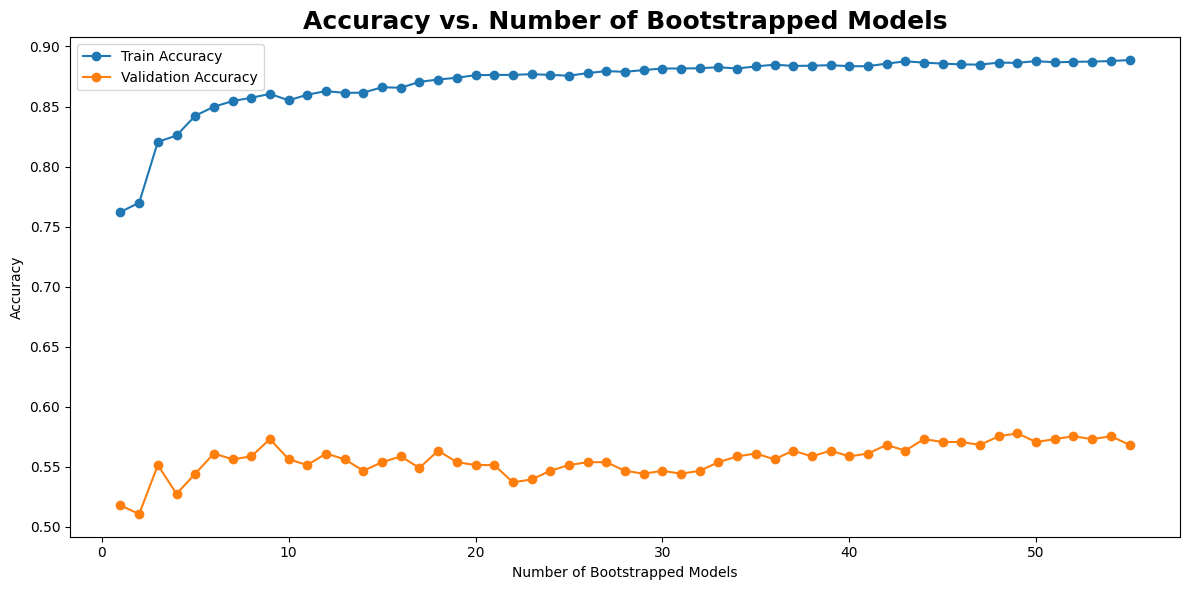

In [90]:
train_accuracies = running_predictions(bagging_train_df, y_train.values)
val_accuracies = running_predictions(bagging_val_df, y_val.values)

plt.figure(figsize=(12, 6))

n_boots = range(1, 56)
#Plot train and test accuracies
plt.plot(n_boots, train_accuracies, label = "Train Accuracy", marker="o")
plt.plot(n_boots, val_accuracies, label = "Validation Accuracy", marker="o")
plt.xlabel("Number of Bootstrapped Models")
plt.ylabel("Accuracy")
plt.title("Accuracy vs. Number of Bootstrapped Models", fontsize=18, fontweight='bold')
plt.legend()
plt.tight_layout()

In the plot above, we see the difference between the train accuracy and validation accuracy of our bagging model. This discrepancy may imply some level of overfitting, or lack of generalizability in our bagging model, which may be due to high correlation between bootstrapped trees which likely creates a lower validation score.

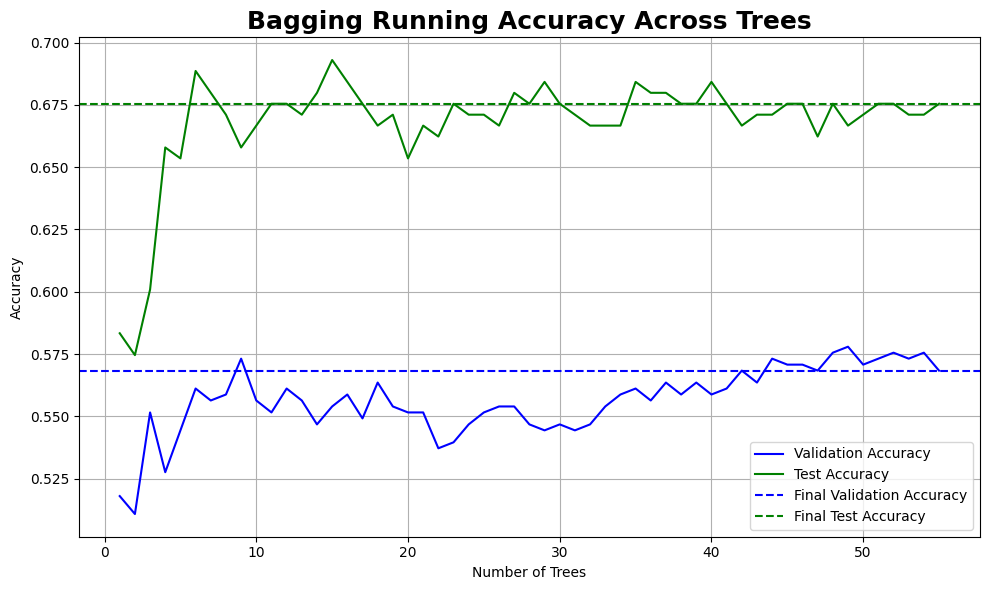

In [91]:
# Visualize the running accuracy of the models
running_val_accuracies = running_predictions(bagging_val_df, y_val.values)
running_test_accuracies = running_predictions(bagging_test_df, y_test.values)

# Plot the running accuracies
plt.figure(figsize=(10, 6))
plt.plot(running_val_accuracies, label="Validation Accuracy", color="blue")
plt.plot(running_test_accuracies, label="Test Accuracy", color="green")
plt.axhline(y=bagging_accuracy_val, color="blue", linestyle="--", label="Final Validation Accuracy")
plt.axhline(y=bagging_test_accuracy, color="green", linestyle="--", label="Final Test Accuracy")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Bagging Running Accuracy Across Trees", fontsize=18, fontweight='bold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

The plot above demonstrates the test and validation accuracies plotted against one another, the two plots show convergence to their ultimate values around the 55 tree level, our chosen # of trees for this model. Likewise, we observe that test accuracy is higher than validation accuracy, likely due to slight differences in year-to-year competition levels, which impacts the two dataset (validation and test)

## 4.5: Random Forest

### 4.5.1 Motivation and Description

Next, we employ another ensemble learning method, Random Forest which creates a diverse ensemble of decision trees, whose predictions are aggregated (via majority voting for classification tasks like ours) to generate the final predictions. Random Forest introduces randomness beyond the scope of a single decision tree in two ways:
$1.$ By training each tree on a bootstrapped sample of the data, and
$2.$ By selecting a random subset of features at each split during tree construction.

Mathematically, RF is derived as follows in our classification context:
Given a dataset $\{(x_i, y_i)\}_{i=1}^n$:

$1.$ Generate $B$ bootstrapped samples $\{(x_i^b, y_i^b)\}$ for $b=1, \dots, B$.  

$2.$ Train a decision tree $f_b(x)$ on each bootstrapped sample, with:
$-$ Random feature selection at each split.  
$-$ Maximum tree depth (hyperparameter).

$3.$ Combine predictions from all trees:
$$
\hat{y} = \underset{y}{\text{argmax }} \sum_{b=1}^B \mathbb{I}(f_b(x) = y)
$$


\subsection*{Advantages of Random Forest}
We choose RF for is advantages in handling high-dimensional data and captures complex feature interactions. Likewise, RF maintains a strong level of interpretability necessary to informing future model iterations via feature importance.

### 4.5.2: Code

In [92]:
# Define features and target
features = [
    'grid', 'lastYearStrength', 'racerMomentum',
    'driverSpreadRace', 'driverSpreadSeason', 'standardTeamCarScoreByRace',
    'averagePitStopTime', 'position_change', 'constructorSeasonPitStopStrengthScore',
    'standarizedPitStopTeamScore', 'laps','elo_score'
]
target = 'position_bucket'

# Separate features and targets for each set
X_train = train_data[features]
y_train = train_data[target]

X_val = val_data[features]
y_val = val_data[target]

X_test = test_data[features]
y_test = test_data[target]

# Train a RandomForest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

train_accuracy = model.score(X_train, y_train)

# Evaluate the model
val_accuracy = model.score(X_val, y_val)
print(f"Validation Accuracy: {val_accuracy:.2f}")

# Evaluate the model on the test set
test_accuracy = model.score(X_test, y_test)
print(f"Test Accuracy: {test_accuracy:.2f}")

Validation Accuracy: 0.59
Test Accuracy: 0.69


In [93]:
model_results = update_model_results(
    model_results=model_results,
    model_number="4.5.2",
    model_name="Random Forest",
    train_accuracy=train_accuracy,
    val_accuracy=val_accuracy,
    test_accuracy=test_accuracy
)
print(model_results)

{'4.2.2': {'Model Name': 'Majority Classification', 'Train Accuracy': None, 'Validation Accuracy': 0.31654676258992803, 'Test Accuracy': 0.2894736842105263}, '4.3.2': {'Model Name': 'Logistic Classifier', 'Train Accuracy': 0.6267891476180303, 'Validation Accuracy': 0.580335731414868, 'Test Accuracy': 0.6096491228070176}, '4.4.2': {'Model Name': 'Bagging', 'Train Accuracy': 0.8886989959410383, 'Validation Accuracy': 0.5683453237410072, 'Test Accuracy': 0.6754385964912281}, '4.5.2': {'Model Name': 'Random Forest', 'Train Accuracy': 0.9535528871103003, 'Validation Accuracy': 0.5856963131774846, 'Test Accuracy': 0.6894948005698005}}


### 4.5.3: Results

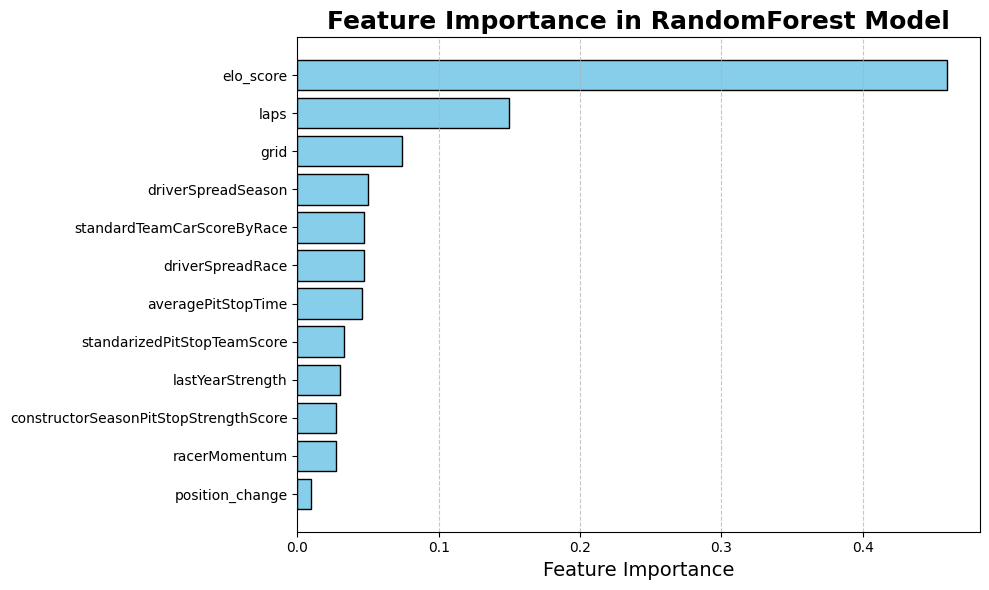

In [94]:
# Feature importance
importances = model.feature_importances_

# Create a DataFrame for sorting
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
})

# Sort the DataFrame by importance
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue', edgecolor='black')
plt.xlabel('Feature Importance', fontsize=14)
plt.title('Feature Importance in RandomForest Model', fontsize=18, fontweight='bold')
plt.gca().invert_yaxis()  # Invert y-axis to show the most important feature at the top
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Above we see that elo_score is far and away the best predictor of finishing position bucket for our RandomForest model. This implies that the historical, iterative score calculation being done in this variable helps represent well how these racers will perform in the future. One can also assume that elo_score is adequately capturing differences in drivers that then manifest themselves in different finishing positions, making it the most important feature, beyond starting position or even laps completed.

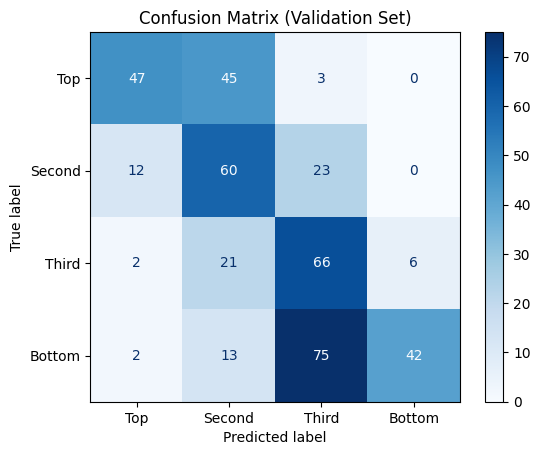

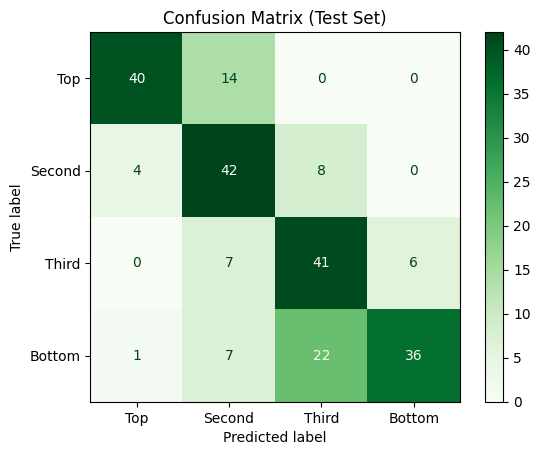

In [95]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict on validation and test sets
y_val_pred = model.predict(X_val)
y_test_pred = model.predict(X_test)

# Round predictions to the nearest integer and ensure they match the bucket range
y_val_pred_discrete = y_val_pred.round().astype(int).clip(0, 3)  # Assuming 4 buckets: 0, 1, 2, 3
y_test_pred_discrete = y_test_pred.round().astype(int).clip(0, 3)

# Confusion matrix for validation set
val_conf_matrix = confusion_matrix(y_val, y_val_pred_discrete, labels=[0, 1, 2, 3])

# Plot confusion matrix for validation set
disp = ConfusionMatrixDisplay(confusion_matrix=val_conf_matrix, display_labels=["Top", "Second", "Third", "Bottom"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix (Validation Set)")
plt.show()

# Confusion matrix for test set
test_conf_matrix = confusion_matrix(y_test, y_test_pred_discrete, labels=[0, 1, 2, 3])

# Plot confusion matrix for test set
disp = ConfusionMatrixDisplay(confusion_matrix=test_conf_matrix, display_labels=["Top", "Second", "Third", "Bottom"])
disp.plot(cmap="Greens", values_format="d")
plt.title("Confusion Matrix (Test Set)")
plt.show()

In the confusion matrices above, we see that Random Forest performs overall well on classifying across the 4 different buckets. Interestingly, it misclassifies many of the top drivers by projecting them to finish in the second bucket, while also classifying many of the bottom drivers to finish in the 3rd bucket. This dynamic may imply that it is much more difficult to distinguish between worse racers than better ones, but also that generally the top and bottom are hardest to predict in comparision to the middle classes, which have less misclassification.

## 4.6: AdaBoost

### Motivation and Description
Next, we employ another ensemble learning algo, AdaBoost, which combines multiple weak classifiers, such as decision trees, to create a strong classifier. By focusing on misclassfied samples, AdaBoost iteratively trains weak learners on weighted versions of the data and combines their outputs.

Mathematically formulated, AdaBoost performs the following:
Given a dataset $\{(x_i, y_i)\}_{i=1}^n$ with $n$ training samples:

1. Initialize weights for all samples:
   $$
   w_i = \frac{1}{n}, \, i=1, \dots, n
   $$

2. For each weak learner $t = 1, \dots, T$:
   - Train a weak classifier $h_t(x)$ using the current sample weights $w_i$.
   - Compute the weighted error of the weak classifier:
     $$
     \epsilon_t = \frac{\sum_{i=1}^n w_i \cdot \mathbb{I}(h_t(x_i) \neq y_i)}{\sum_{i=1}^n w_i}
     $$
     where $\mathbb{I}$ is the indicator function, equal to 1 if the prediction is incorrect and 0 otherwise.
   - Compute weight of the weak classifier:
     $$
     \alpha_t = \frac{1}{2} \ln\left(\frac{1 - \epsilon_t}{\epsilon_t}\right)
     $$
   - Update sample weights:
     $$
     w_i \leftarrow w_i \cdot \exp\left(\alpha_t \cdot \mathbb{I}(h_t(x_i) \neq y_i)\right)
     $$
   - Normalize weights:
     $$
     w_i \leftarrow \frac{w_i}{\sum_{j=1}^n w_j}
     $$

3. The final model is a weighted combination of the weak classifiers:
   $$
   H(x) = \text{sign}\left(\sum_{t=1}^T \alpha_t h_t(x)\right)
   $$

\subsection*{Advantages of AdaBoost}

- AdaBoost focuses on hard-to-classify examples, improving performance on challenging datasets.
- The sequential training of weak learners allows the model to adapt dynamically to misclassifications.
- It is robust to overfitting for a moderate number of iterations.


Ulimately, we employ AdaBoost to consider the key factors that might cause misclassification across different models, focusing on samples that might be the hardest to classify across the entire dataset which previous models haven't handled well. We are unsure whether it will fundamentally provide improvement, however, it does focus on a different element of the overall dataset.

### 4.6.2: Code

In [96]:
# Preprocess features and target
features = [
    'grid', 'rank', 'laps',
    'averagePitStopTime', 'averageTeamPitStopTimePerRace',
    'standarizedPitStopTeamScore', 'constructorSeasonPitStopStrengthScore', 'lastYearStrength', 'elo_score'
]
target = 'position_bucket'  # Target variable for classification

# Extract features and target
X_train = train_data[features]
y_train = train_data[target]

X_val = val_data[features]
y_val = val_data[target]

X_test = test_data[features]
y_test = test_data[target]

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.1

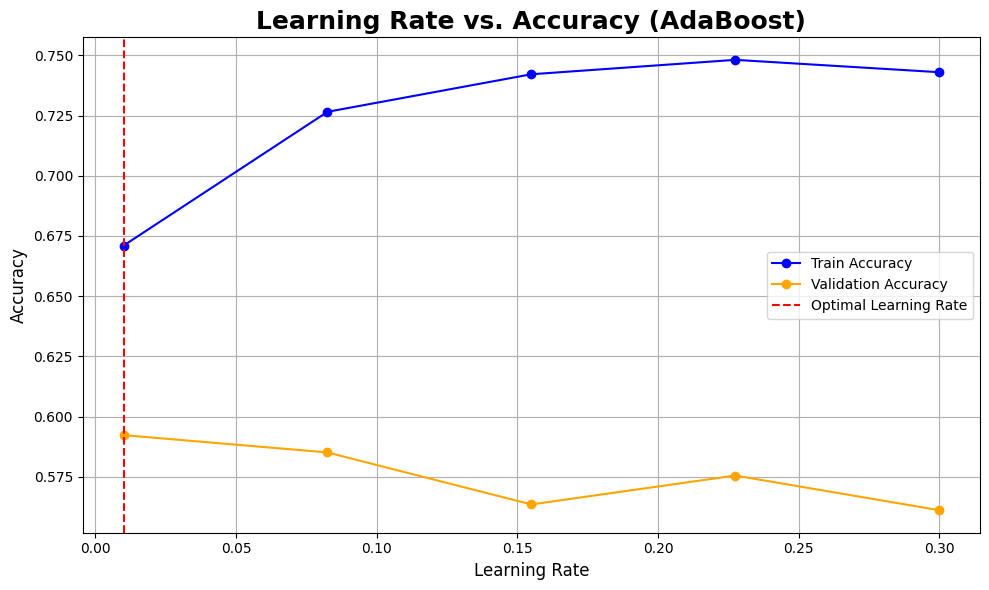

Optimal Learning Rate: 0.0100
Train Accuracy at Optimal Learning Rate: 0.6710
Validation Accuracy at Optimal Learning Rate: 0.5923


In [97]:
learning_rates = np.linspace(0.01, 0.3, 5)

# Initialize lists to store results
train_accuracies = []
val_accuracies = []

# Iterate over the learning rates
for lr in learning_rates:
    # Define and train the AdaBoost model
    adaboost = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3),
        n_estimators=800,
        learning_rate=lr,
        algorithm='SAMME.R',
        random_state=0
    )
    adaboost.fit(X_train, y_train)

    # Compute final training and validation accuracies
    train_accuracies.append(adaboost.score(X_train, y_train))
    val_accuracies.append(adaboost.score(X_val, y_val))

# Plot the learning rate vs. accuracies
plt.figure(figsize=(10, 6))
plt.plot(learning_rates, train_accuracies, marker='o', label='Train Accuracy', color='blue')
plt.plot(learning_rates, val_accuracies, marker='o', label='Validation Accuracy', color='orange')

# Annotate plot
plt.title('Learning Rate vs. Accuracy (AdaBoost)', fontsize=18, fontweight='bold')
plt.xlabel('Learning Rate', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.axvline(learning_rates[np.argmax(val_accuracies)], color='red', linestyle='--', label='Optimal Learning Rate')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Print the optimal learning rate
optimal_lr = learning_rates[np.argmax(val_accuracies)]
print(f"Optimal Learning Rate: {optimal_lr:.4f}")
print(f"Train Accuracy at Optimal Learning Rate: {train_accuracies[np.argmax(val_accuracies)]:.4f}")
print(f"Validation Accuracy at Optimal Learning Rate: {max(val_accuracies):.4f}")

The plot above aids us in our selection of optimal learning rate, showing where validation accuracy is optimal and using that value for our selection.

In [98]:
# Define and train the AdaBoost model
adaboost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3),
    n_estimators=800,
    learning_rate=0.01,
    algorithm='SAMME.R',
    random_state=0
)

adaboost.fit(X_train, y_train)

# Calculate train and validation accuracies using staged_score
train_accuracies = list(adaboost.staged_score(X_train, y_train))
val_accuracies = list(adaboost.staged_score(X_val, y_val))
test_accuracy = adaboost.score(X_test, y_test)

# Print the final accuracies
print(f"Final Train Accuracy: {train_accuracies[-1]:.4f}")
print(f"Final Validation Accuracy: {val_accuracies[-1]:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

/usr/local/lib/python3.10/dist-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/sklearn/base.py:493: UserWarning: X does not have valid feature names, but AdaBoostClassifier was fitted with feature names
  warnings.warn(


Final Train Accuracy: 0.6710
Final Validation Accuracy: 0.5923
Test Accuracy: 0.6974


In [99]:
model_results = update_model_results(
    model_results=model_results,
    model_number="4.6.2",
    model_name="AdaBoost",
    train_accuracy=train_accuracies[-1],
    val_accuracy=val_accuracies[-1],
    test_accuracy=test_accuracy
)

# Print the updated model results
print(model_results)

{'4.2.2': {'Model Name': 'Majority Classification', 'Train Accuracy': None, 'Validation Accuracy': 0.31654676258992803, 'Test Accuracy': 0.2894736842105263}, '4.3.2': {'Model Name': 'Logistic Classifier', 'Train Accuracy': 0.6267891476180303, 'Validation Accuracy': 0.580335731414868, 'Test Accuracy': 0.6096491228070176}, '4.4.2': {'Model Name': 'Bagging', 'Train Accuracy': 0.8886989959410383, 'Validation Accuracy': 0.5683453237410072, 'Test Accuracy': 0.6754385964912281}, '4.5.2': {'Model Name': 'Random Forest', 'Train Accuracy': 0.9535528871103003, 'Validation Accuracy': 0.5856963131774846, 'Test Accuracy': 0.6894948005698005}, '4.6.2': {'Model Name': 'AdaBoost', 'Train Accuracy': 0.6710104678487503, 'Validation Accuracy': 0.592326139088729, 'Test Accuracy': 0.6973684210526315}}


### 4.6.3: Results

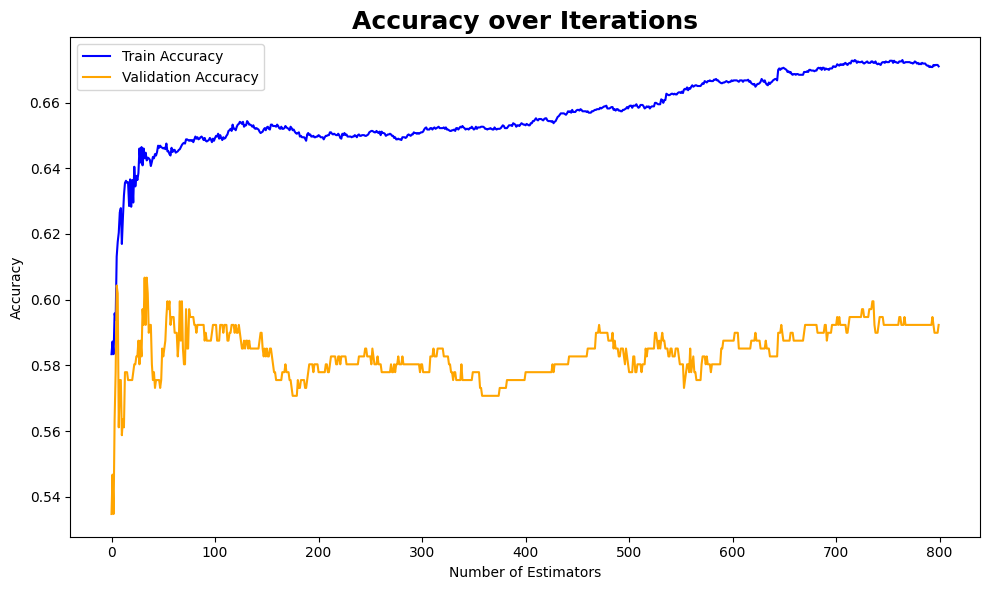

In [100]:
plt.figure(figsize=(10, 6))
plt.plot(train_accuracies, label='Train Accuracy', color='blue')
plt.plot(val_accuracies, label='Validation Accuracy', color='orange')
plt.xlabel('Number of Estimators')
plt.ylabel('Accuracy')
plt.title('Accuracy over Iterations', fontsize=18, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

The above plot compares the train accuracy and validation accuracy across the different # of iterations for our AdaBoost model. We observe that aside from significant variation at the beginning, the validation accuracy stabilizes beyond 500-800 estimators, which we find to be the optimal amount to refine our classification of initially misclassified samples with AdaBoost

## 4.7: XGBoost

### 4.7.1: Motivation and Description

Lastly, we wanted to try out XGBoost (eXtreme Gradient Boosting), an ensemble learning method we admittedly did not fully flesh out in class, though one we believe could be interesting to consider in our context. Because to this point we have not incorporated regularization, we wanted to consider it through the context of gradient boosting (another method not considered to this point). By penalizing overly complex trees and focusing on meaningful splits, XGBoost ensures that the features under consideration will contribute to and create generalizable predictions.

Mathematically, XGBoost is extremely complex, though its simple derviation can be considered as follows:
\section*{Mathematical Formulation of XGBoost}

XGBoost is focused on minimizing the following objective function:

$$
\mathcal{L}(\Theta) = \sum_{i=1}^{n} \ell(y_i, \hat{y}_i) + \sum_{k=1}^{K} \Omega(f_k)
$$

Where:
- $\ell(y_i, \hat{y}_i) $: Loss function (e.g., log-loss for classification).
- $\Omega(f_k) = \gamma T + \frac{1}{2} \lambda \sum_{j=1}^{T} w_j^2$: Regularization term for tree complexity.

At each step $ t $, XGBoost updates the predictions:

$$
\hat{y}_i^{(t)} = \hat{y}_i^{(t-1)} + f_t(x_i)
$$

Each tree minimizes the following approximation of the loss:

$$
\mathcal{L}^{(t)} = \sum_{i=1}^{n} \left[ g_i f_t(x_i) + \frac{1}{2} h_i f_t^2(x_i) \right]
$$

Where:
- $g_i $: Gradient of the loss.
- $ h_i $: Second derivative (Hessian) of the loss.

The final prediction is given by summing over all trees:
$$
\hat{y}_i = \sum_{k=1}^{K} f_k(x_i)
$$




### 4.7.2: Code

In [101]:
# Ensure all features are numeric
X_train = train_data[features].apply(pd.to_numeric, errors='coerce')
X_val = val_data[features].apply(pd.to_numeric, errors='coerce')
X_test = test_data[features].apply(pd.to_numeric, errors='coerce')

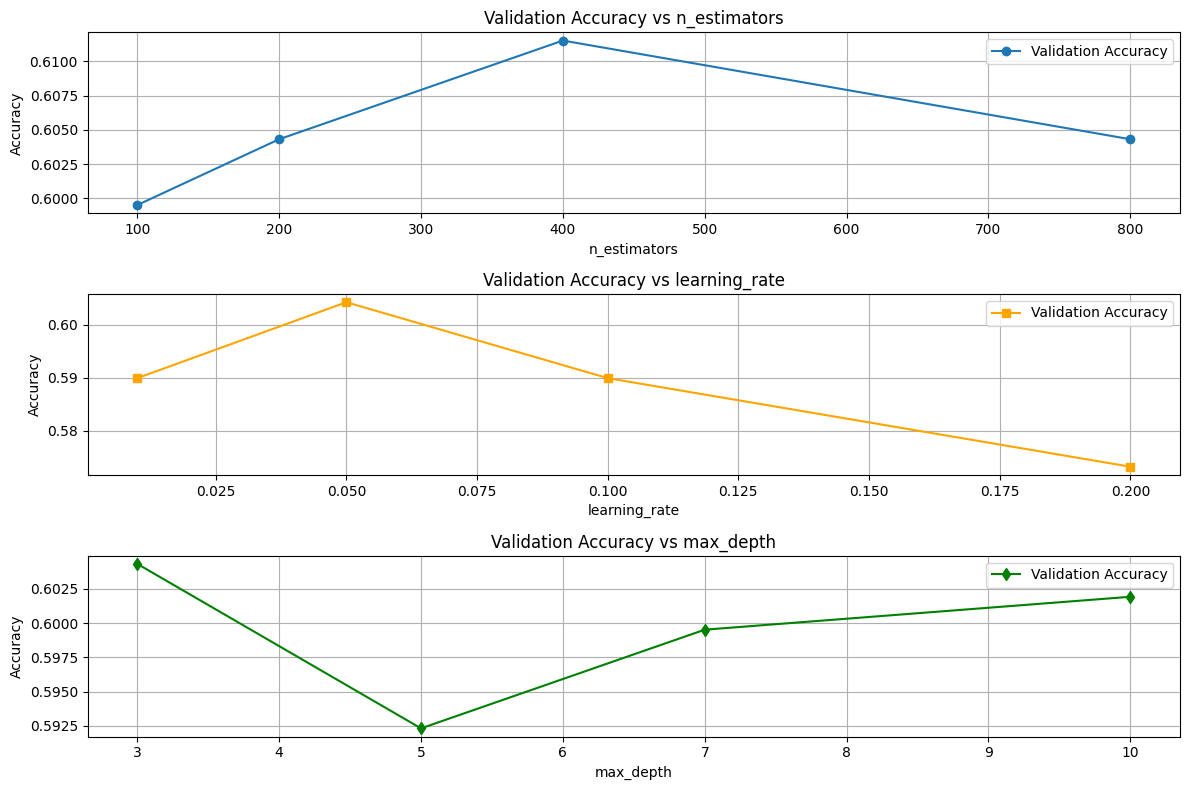

In [102]:
n_estimators_range = [100, 200, 400, 800]
learning_rate_range = [0.01, 0.05, 0.1, 0.2]
max_depth_range = [3, 5, 7, 10]

# Function to perform simulation for a single parameter
def parameter_tuning(param_name, param_values, X_train, y_train, X_val, y_val):
    results = []

    for value in param_values:
        # Set the parameter dynamically
        params = {
            'n_estimators': 800,
            'learning_rate': 0.05,
            'max_depth': 3,
            'random_state': 42,
            'eval_metric': "mlogloss",
        }
        params[param_name] = value

        # Define and train the model
        model = XGBClassifier(**params)
        model.fit(X_train, y_train)

        # Evaluate the model on validation data
        y_val_pred = model.predict(X_val)
        val_accuracy = accuracy_score(y_val, y_val_pred)
        results.append((value, val_accuracy))

    return results

# Perform simulations for each parameter
n_estimators_results = parameter_tuning('n_estimators', n_estimators_range, X_train, y_train, X_val, y_val)
learning_rate_results = parameter_tuning('learning_rate', learning_rate_range, X_train, y_train, X_val, y_val)
max_depth_results = parameter_tuning('max_depth', max_depth_range, X_train, y_train, X_val, y_val)

# Plot the results
plt.figure(figsize=(12, 8))

# Plot for n_estimators
plt.subplot(3, 1, 1)
plt.plot(*zip(*n_estimators_results), marker='o', label='Validation Accuracy')
plt.title('Validation Accuracy vs n_estimators')
plt.xlabel('n_estimators')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()

# Plot for learning_rate
plt.subplot(3, 1, 2)
plt.plot(*zip(*learning_rate_results), marker='s', label='Validation Accuracy', color='orange')
plt.title('Validation Accuracy vs learning_rate')
plt.xlabel('learning_rate')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()

# Plot for max_depth
plt.subplot(3, 1, 3)
plt.plot(*zip(*max_depth_results), marker='d', label='Validation Accuracy', color='green')
plt.title('Validation Accuracy vs max_depth')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

The above plots serve as a stand-in for GridSearchCV and demonstrate that the optimal n_estimators is 400, the optimal learning rate is .05, and the optimal max_depth is 3, all parameters which we select and use in our model below.

In [103]:
# Define the XGBoost model selected with optimal parameters
xgb_model = XGBClassifier(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    eval_metric="mlogloss"
)

# Train the model
xgb_model.fit(X_train, y_train)

# Predict on training set
y_train_pred = xgb_model.predict(X_train)

# Predict on validation and test sets
y_val_pred = xgb_model.predict(X_val)
y_test_pred = xgb_model.predict(X_test)

# Calculate accuracies
train_accuracy = accuracy_score(y_train, y_train_pred)
val_accuracy = accuracy_score(y_val, y_val_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Print results
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Validation Accuracy: 0.6115
Test Accuracy: 0.6842


In [104]:
# Save the results for the Logistic Classifier model
model_results = update_model_results(
    model_results=model_results,
    model_number="4.7.2",
    model_name="XGBoost",
    train_accuracy=train_accuracy,
    val_accuracy=val_accuracy,
    test_accuracy=test_accuracy
)

# Print the updated model results
print(model_results)

{'4.2.2': {'Model Name': 'Majority Classification', 'Train Accuracy': None, 'Validation Accuracy': 0.31654676258992803, 'Test Accuracy': 0.2894736842105263}, '4.3.2': {'Model Name': 'Logistic Classifier', 'Train Accuracy': 0.6267891476180303, 'Validation Accuracy': 0.580335731414868, 'Test Accuracy': 0.6096491228070176}, '4.4.2': {'Model Name': 'Bagging', 'Train Accuracy': 0.8886989959410383, 'Validation Accuracy': 0.5683453237410072, 'Test Accuracy': 0.6754385964912281}, '4.5.2': {'Model Name': 'Random Forest', 'Train Accuracy': 0.9535528871103003, 'Validation Accuracy': 0.5856963131774846, 'Test Accuracy': 0.6894948005698005}, '4.6.2': {'Model Name': 'AdaBoost', 'Train Accuracy': 0.6710104678487503, 'Validation Accuracy': 0.592326139088729, 'Test Accuracy': 0.6973684210526315}, '4.7.2': {'Model Name': 'XGBoost', 'Train Accuracy': 0.7549668874172185, 'Validation Accuracy': 0.6115107913669064, 'Test Accuracy': 0.6842105263157895}}


### 4.7.3: Results


Feature Importances:
                                 Feature  Importance
0                                   grid    0.253697
1                                   rank    0.245851
8                              elo_score    0.200494
2                                   laps    0.100828
7                       lastYearStrength    0.065204
5            standarizedPitStopTeamScore    0.038771
3                     averagePitStopTime    0.034862
4          averageTeamPitStopTimePerRace    0.032356
6  constructorSeasonPitStopStrengthScore    0.027937


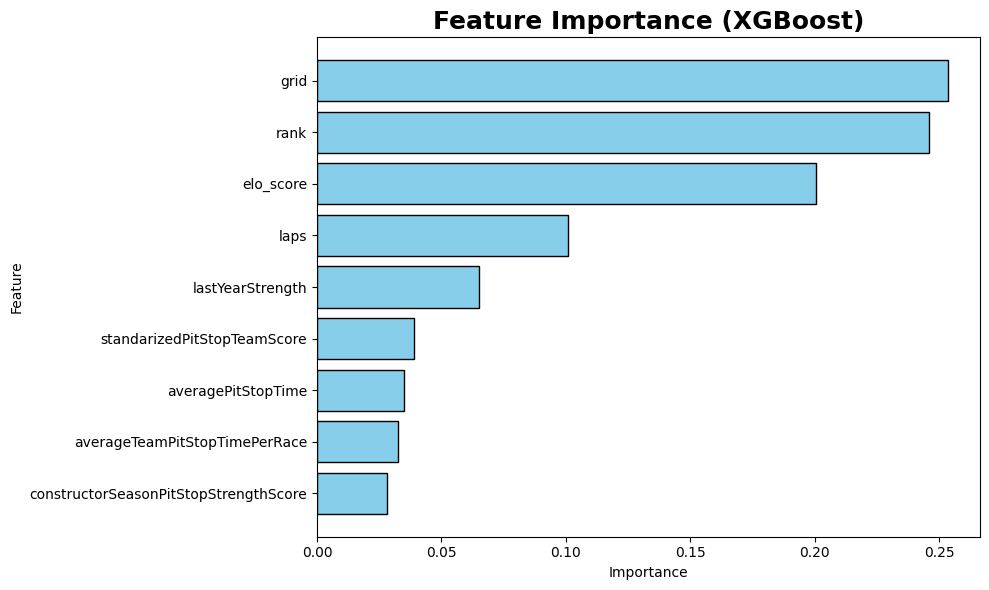


Feature Importances:
                                 Feature  Importance
0                                   grid    0.253697
1                                   rank    0.245851
8                              elo_score    0.200494
2                                   laps    0.100828
7                       lastYearStrength    0.065204
5            standarizedPitStopTeamScore    0.038771
3                     averagePitStopTime    0.034862
4          averageTeamPitStopTimePerRace    0.032356
6  constructorSeasonPitStopStrengthScore    0.027937


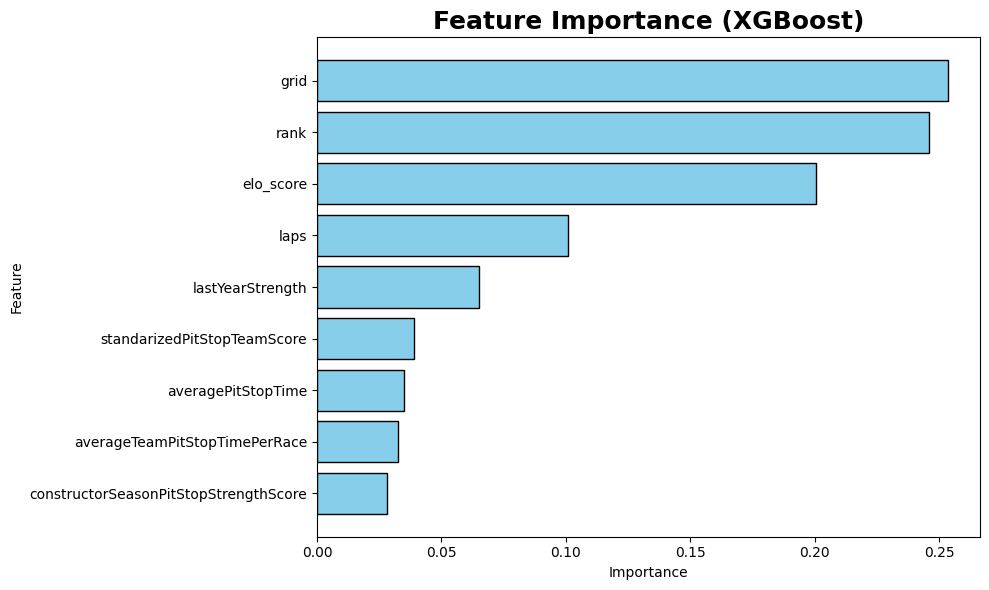

In [105]:
# Feature importance
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importances:")
print(feature_importance)

# Plot feature importance
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='skyblue', edgecolor='black')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Feature Importance (XGBoost)', fontsize=18, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

The plot above shows the feature importances for our XGBoost model, demonstrating that once again rank, grid and elo-Score dominate as the strongest predictors of finishing position. This again suggests that much of F1 outcome is determined by the starting position of the various racers.

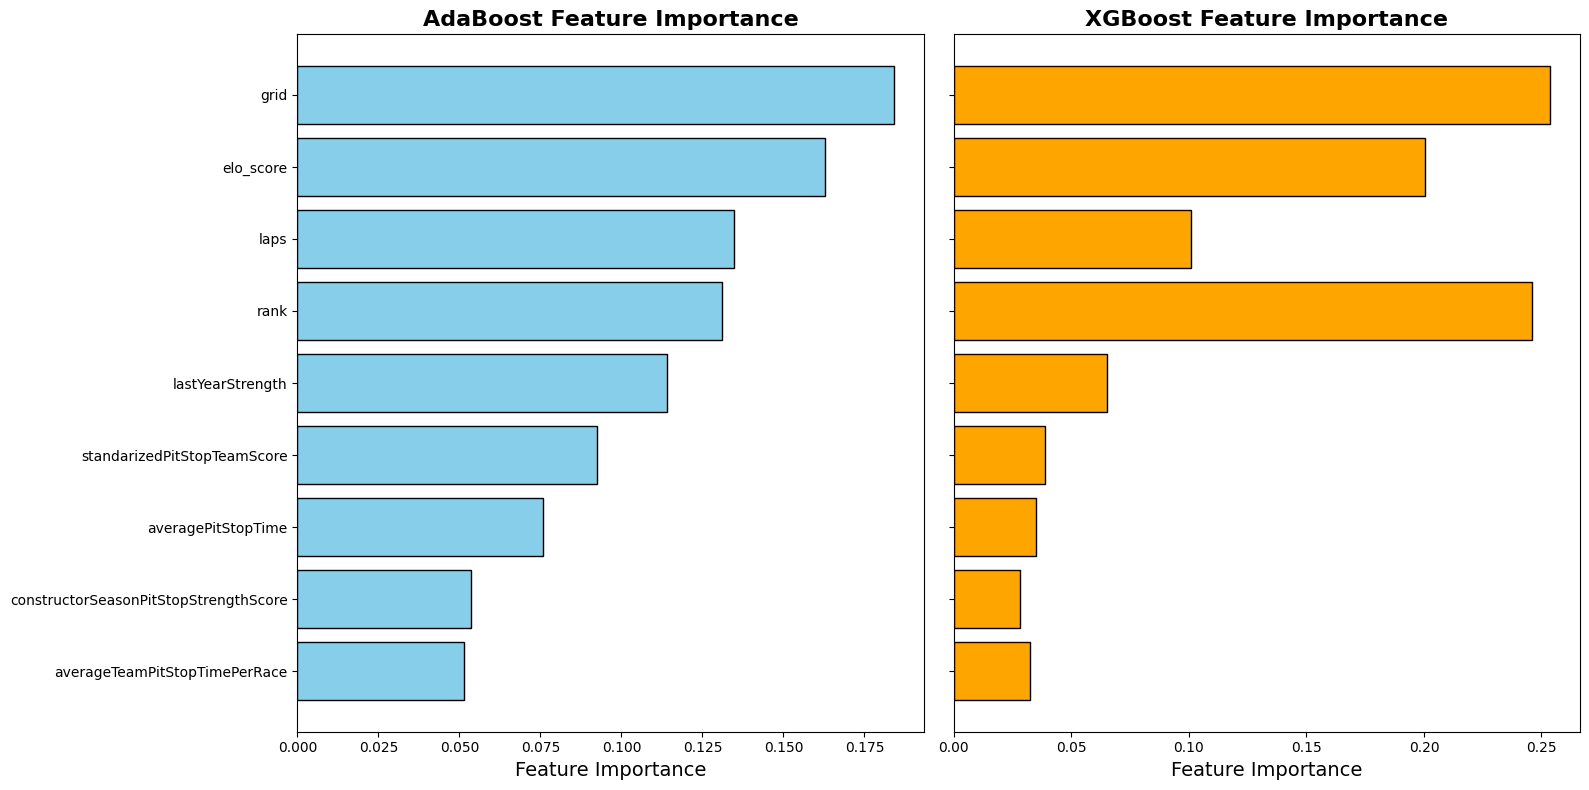

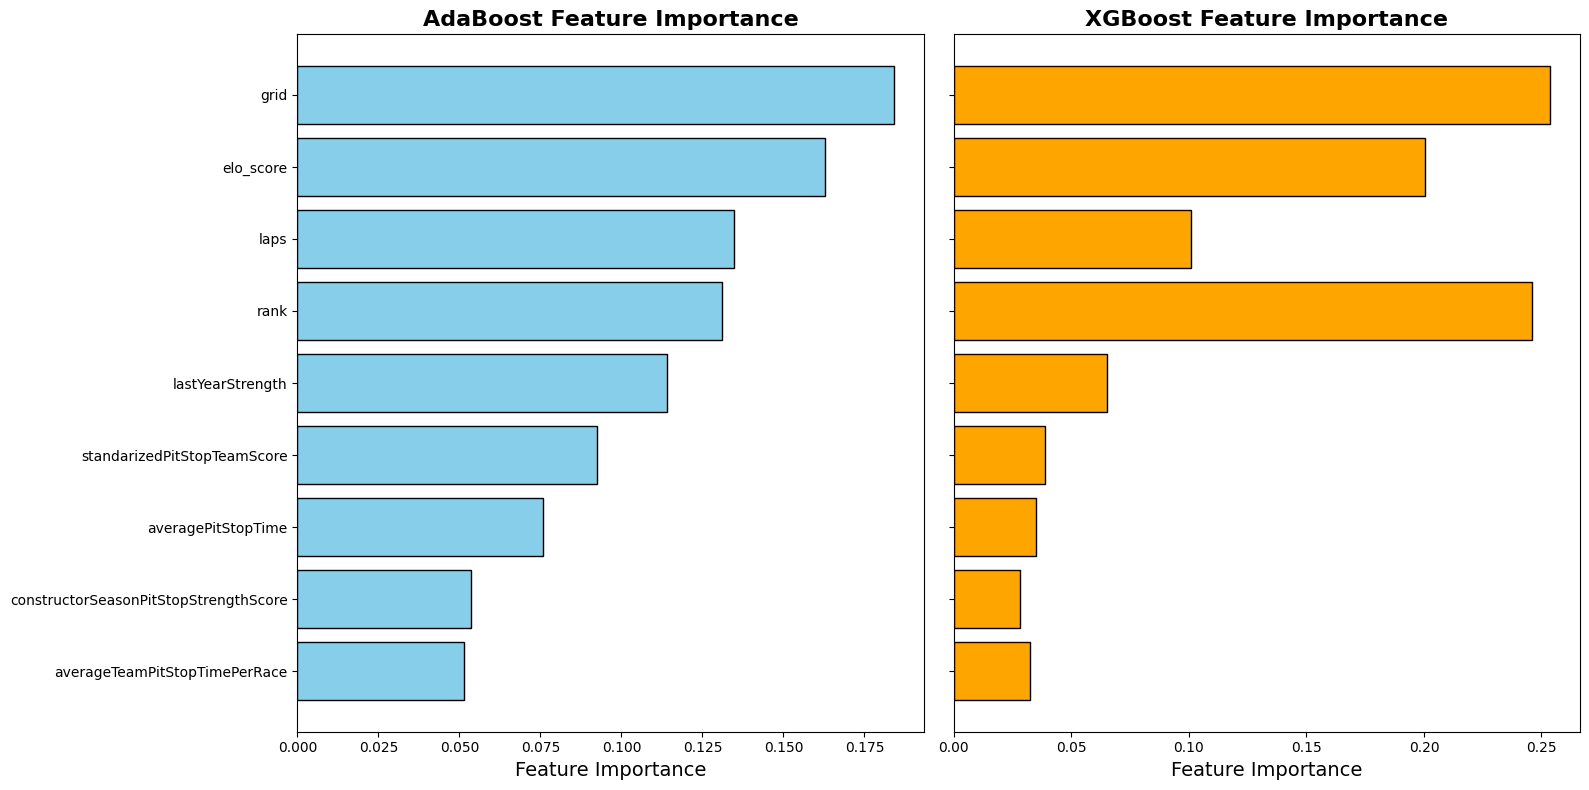

In [106]:
import matplotlib.pyplot as plt
import numpy as np

# Extract feature importances from AdaBoost
adaboost_importances = adaboost.feature_importances_

# Extract feature importances from XGBoost
xgboost_importances = xgb_model.feature_importances_

# Sort features by importance for consistent comparison
sorted_idx_adaboost = np.argsort(adaboost_importances)[::-1]
sorted_idx_xgboost = np.argsort(xgboost_importances)[::-1]

# Create a figure with two subplots for side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

# Plot AdaBoost feature importances
axes[0].barh(
    np.array(features)[sorted_idx_adaboost][::-1],  # Reverse for top-down order
    adaboost_importances[sorted_idx_adaboost][::-1],
    color='skyblue',
    edgecolor='black'
)
axes[0].set_title('AdaBoost Feature Importance', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Feature Importance', fontsize=14)

# Plot XGBoost feature importances
axes[1].barh(
    np.array(features)[sorted_idx_xgboost][::-1],  # Reverse for top-down order
    xgboost_importances[sorted_idx_xgboost][::-1],
    color='orange',
    edgecolor='black'
)
axes[1].set_title('XGBoost Feature Importance', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Feature Importance', fontsize=14)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

The comparision of main feature importances for the AdaBoost model as compared to XGBoost demonstrates that the two boosting methods mainly have similar rankings, except that rank is much more important to XGBoost than it is for Adaboost. This likely pertains to the fact that XGBoost relies on regularization vs AdaBoost which relies on classifying the previously misclassified data.

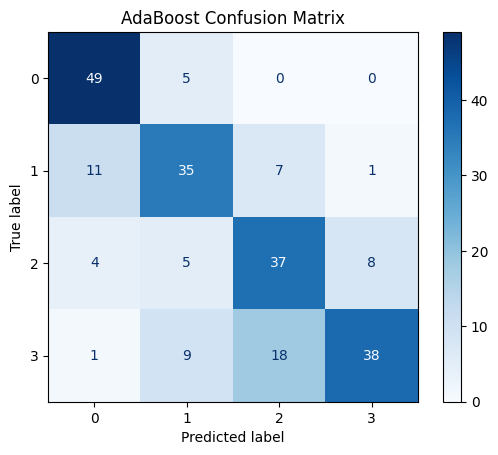

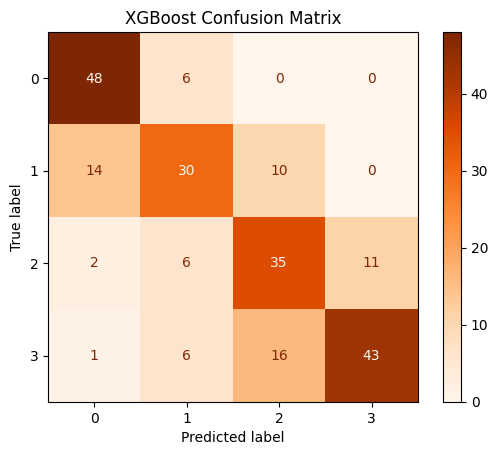

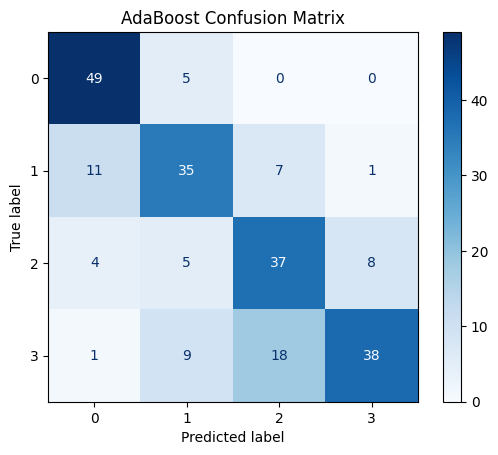

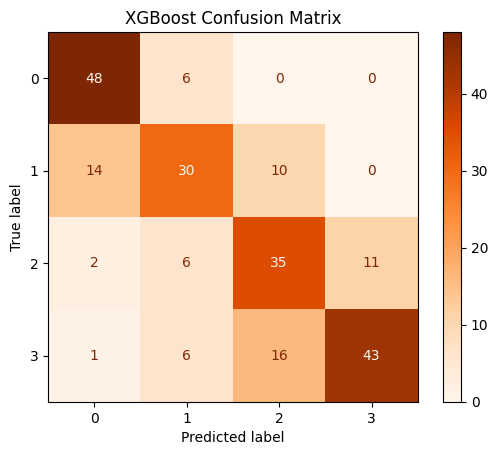

In [107]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

# Generate predictions for the test set
adaboost_test_preds = adaboost.predict(X_test)
xgboost_test_preds = xgb_model.predict(X_test)

# Confusion matrix for AdaBoost
adaboost_cm = confusion_matrix(y_test, adaboost_test_preds)
ConfusionMatrixDisplay(adaboost_cm, display_labels=np.unique(y_test)).plot(
    cmap='Blues', values_format='d'
)
plt.title("AdaBoost Confusion Matrix")
plt.show()

# Confusion matrix for XGBoost
xgboost_cm = confusion_matrix(y_test, xgboost_test_preds)
ConfusionMatrixDisplay(xgboost_cm, display_labels=np.unique(y_test)).plot(
    cmap='Oranges', values_format='d'
)
plt.title("XGBoost Confusion Matrix")
plt.show()

The above plot compares the confusion matrices for the different boosting models demonstrate that the top and bottom buckets are the hardest to predict for these models, with the most misclassification occuring in those instances.

# SECTION 5: RESULTS AND DISCUSSION

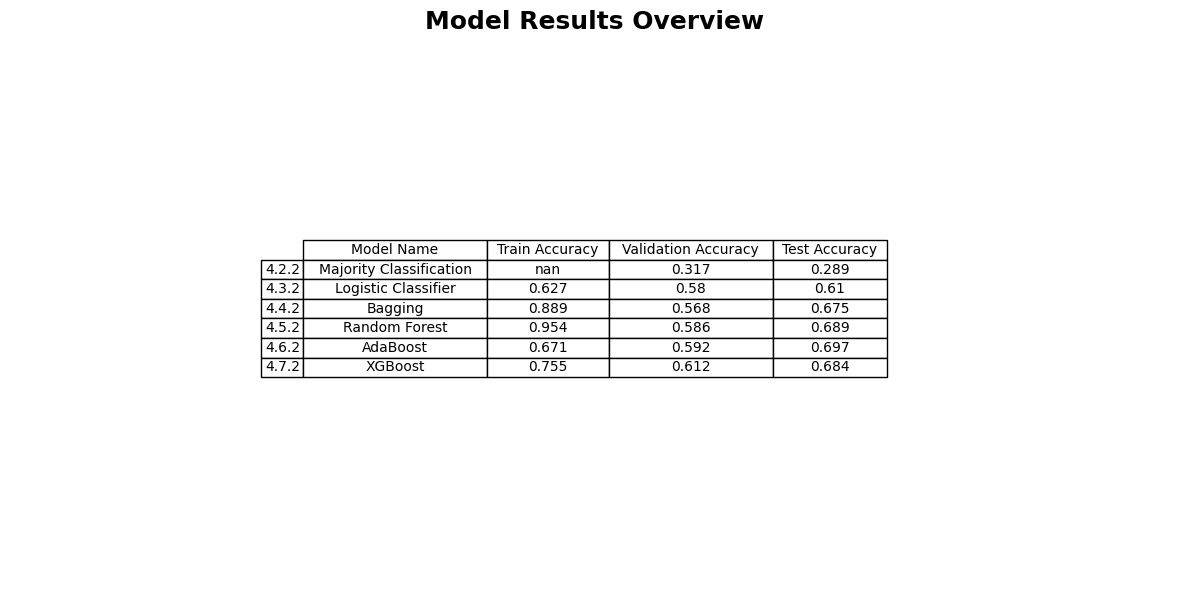

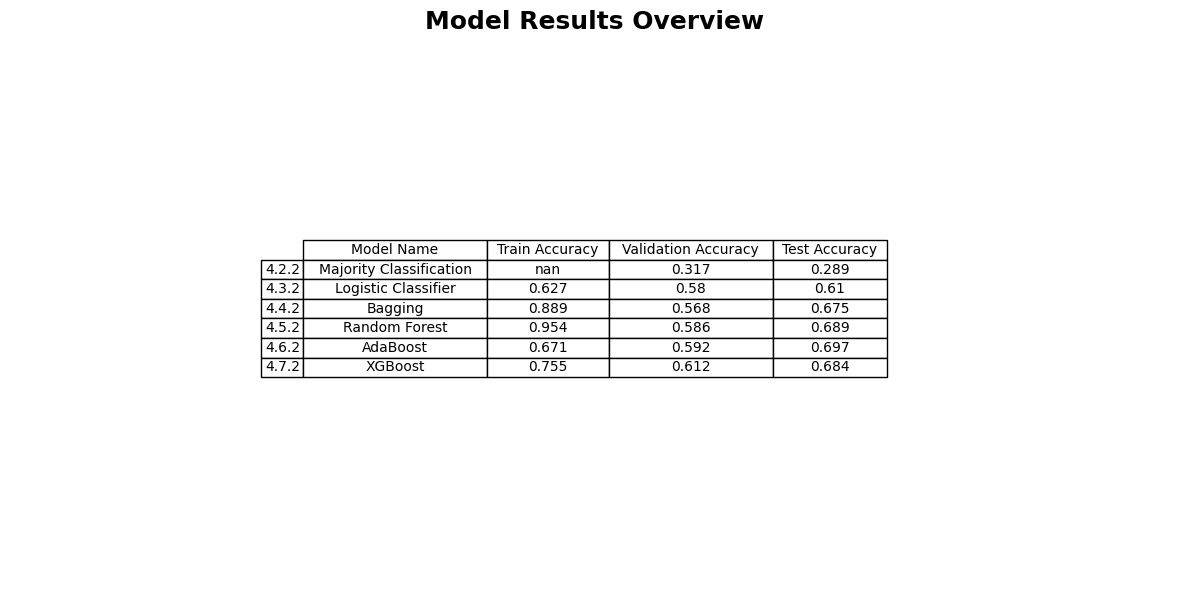

In [108]:
# Format the DataFrame to show only 3 decimal points
model_results_df = pd.DataFrame.from_dict(model_results, orient='index')
model_results_df = model_results_df.round(3)

# Plot the table
fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('tight')
ax.axis('off')

# Create the table
table = ax.table(
    cellText=model_results_df.values,
    colLabels=model_results_df.columns,
    rowLabels=model_results_df.index,
    cellLoc='center',
    loc='center'
)

# Adjust table properties
table.auto_set_font_size(False)
table.set_fontsize(10)
table.auto_set_column_width(col=list(range(len(model_results_df.columns))))

plt.title("Model Results Overview", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

The above plot shows that XGBoost ends up being the best performing model.

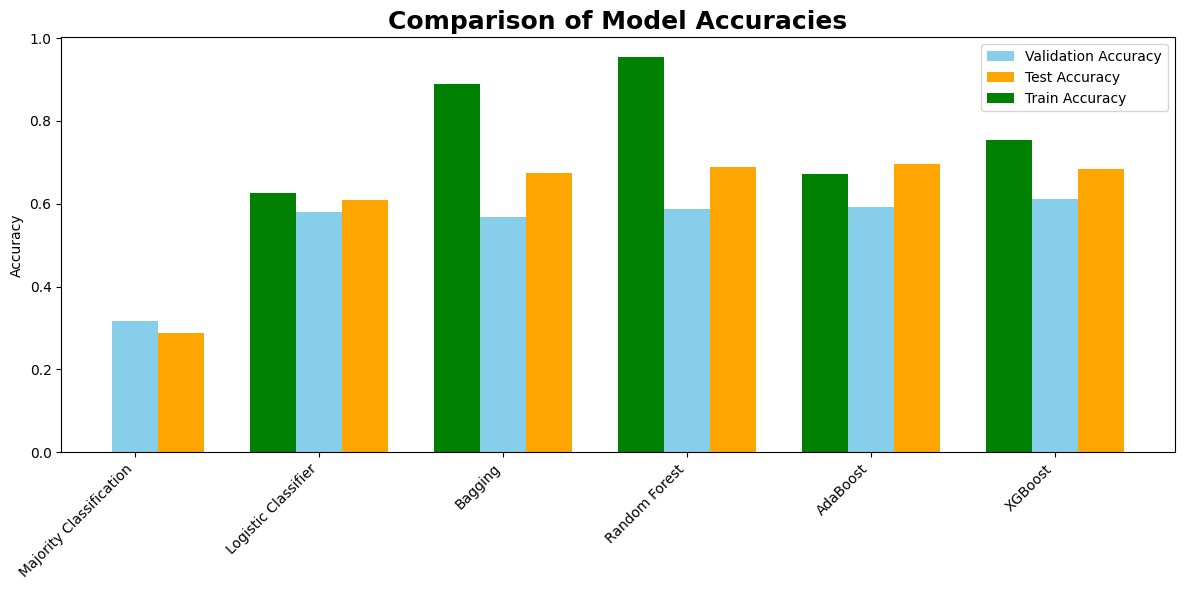

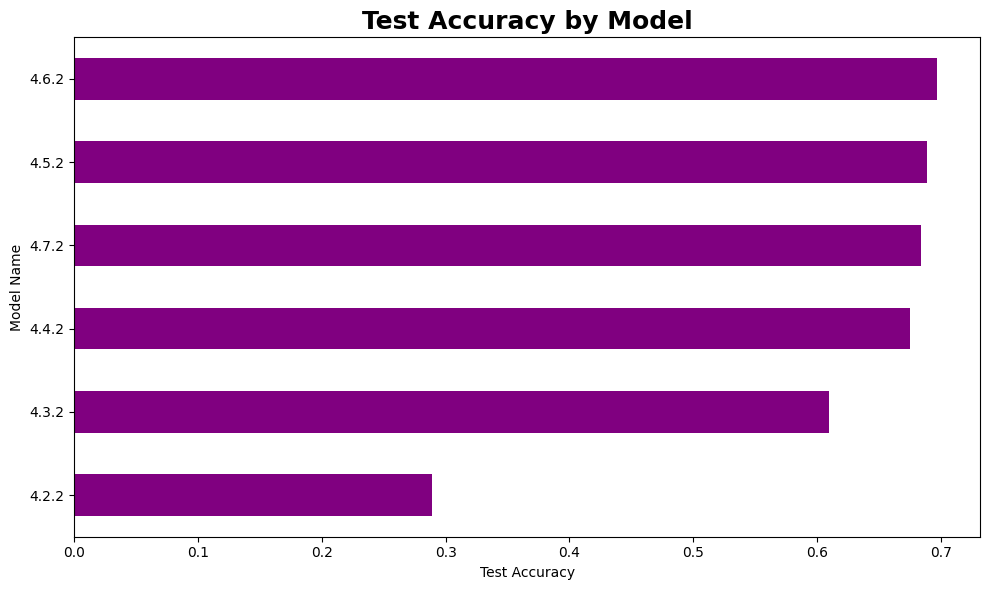

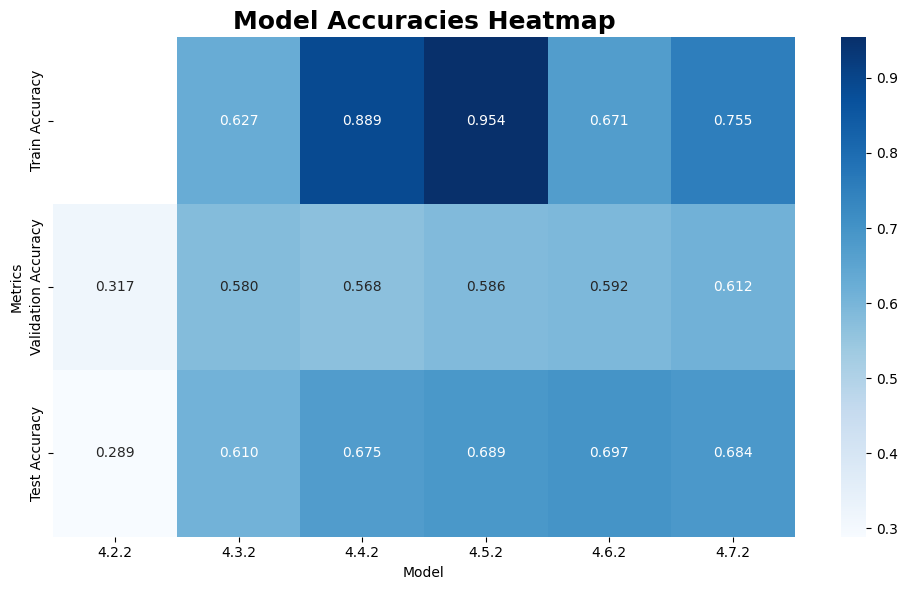

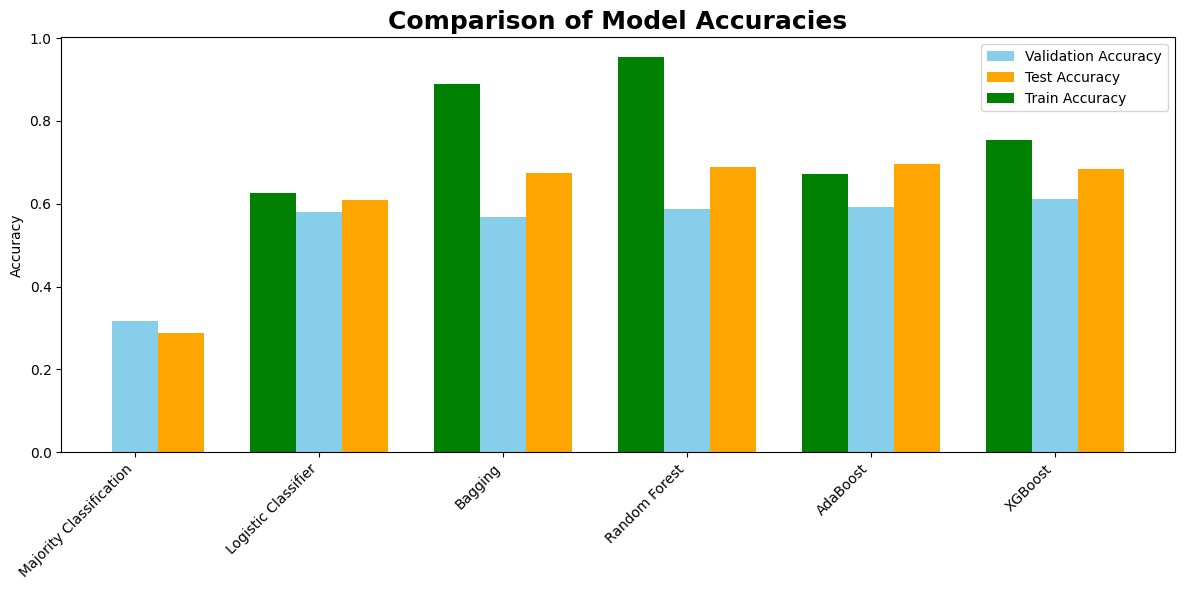

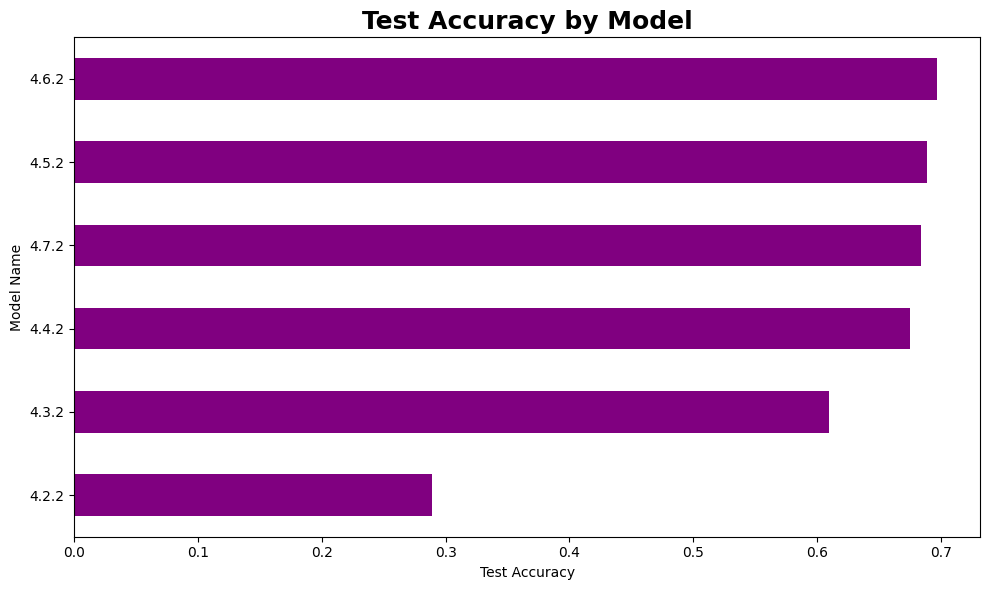

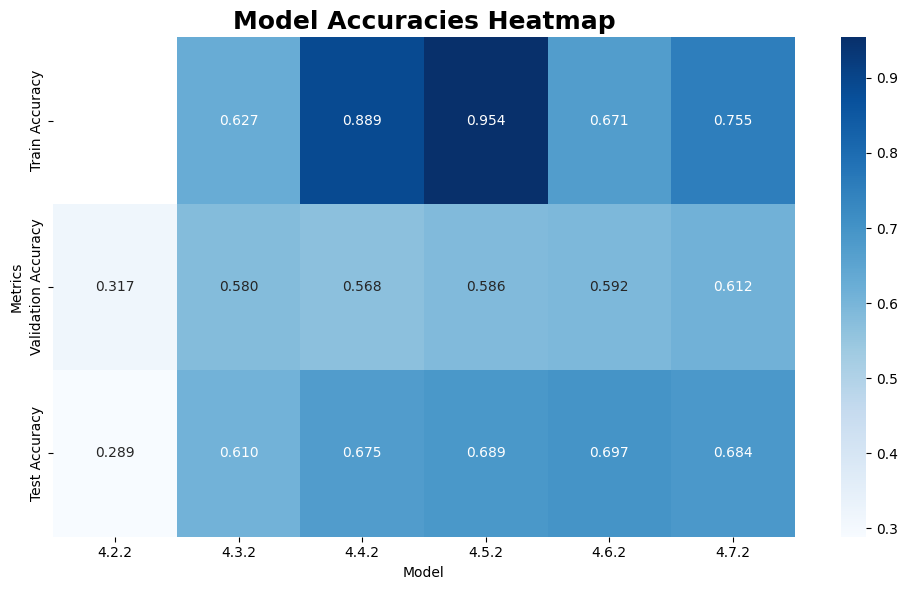

In [109]:
# Bar plot for Train, Validation, and Test Accuracies
plt.figure(figsize=(12, 6))
width = 0.25
x = range(len(model_results_df))

plt.bar(x, model_results_df['Validation Accuracy'], width, label='Validation Accuracy', color='skyblue')
plt.bar([i + width for i in x], model_results_df['Test Accuracy'], width, label='Test Accuracy', color='orange')

if model_results_df['Train Accuracy'].notna().any():
    plt.bar([i - width for i in x], model_results_df['Train Accuracy'], width, label='Train Accuracy', color='green')

# Add labels, title, and legend
plt.xticks(x, model_results_df['Model Name'], rotation=45, ha='right')
plt.ylabel('Accuracy')
plt.title('Comparison of Model Accuracies', fontsize=18, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

# Horizontal bar chart for Test Accuracies
plt.figure(figsize=(10, 6))
model_results_df.sort_values('Test Accuracy')['Test Accuracy'].plot(kind='barh', color='purple')
plt.xlabel('Test Accuracy')
plt.ylabel('Model Name')
plt.title('Test Accuracy by Model',fontsize=18, fontweight='bold')
plt.tight_layout()
plt.show()

#heatmap of acuracies
plt.figure(figsize=(10, 6))
sns.heatmap(
    model_results_df.drop(columns=['Model Name']).transpose(),
    annot=True, cmap='Blues', fmt='.3f', cbar=True
)
plt.title('Model Accuracies Heatmap', fontsize=18, fontweight='bold')
plt.xlabel('Model')
plt.ylabel('Metrics')
plt.tight_layout()
plt.show()

The plots above compare the test accuracies, validation accuracies and train accuracies more granularly.

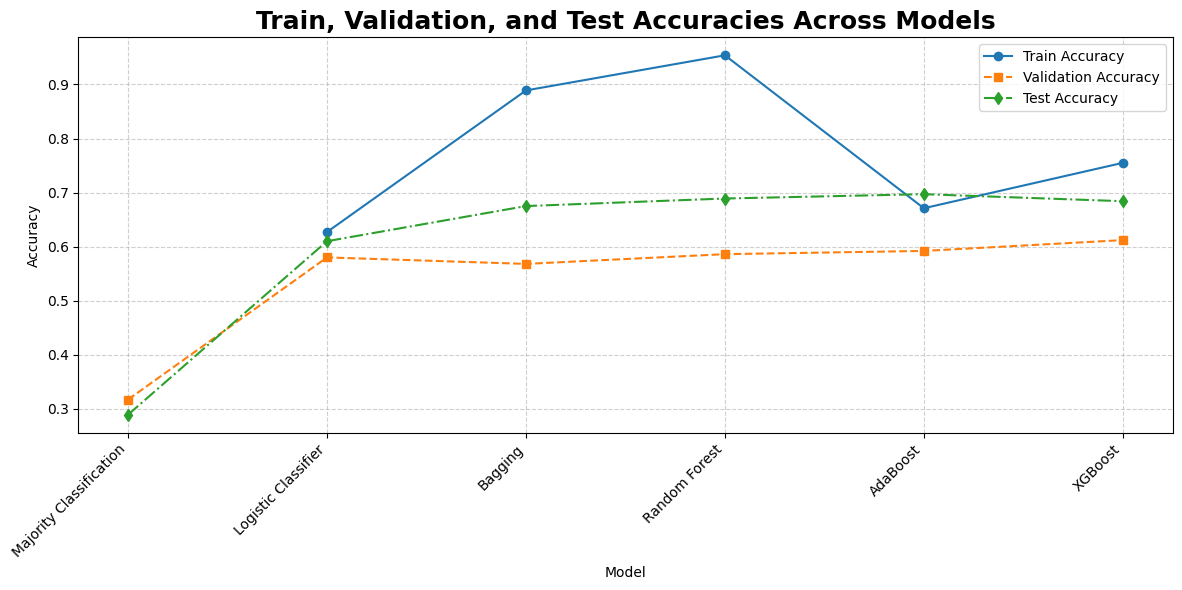

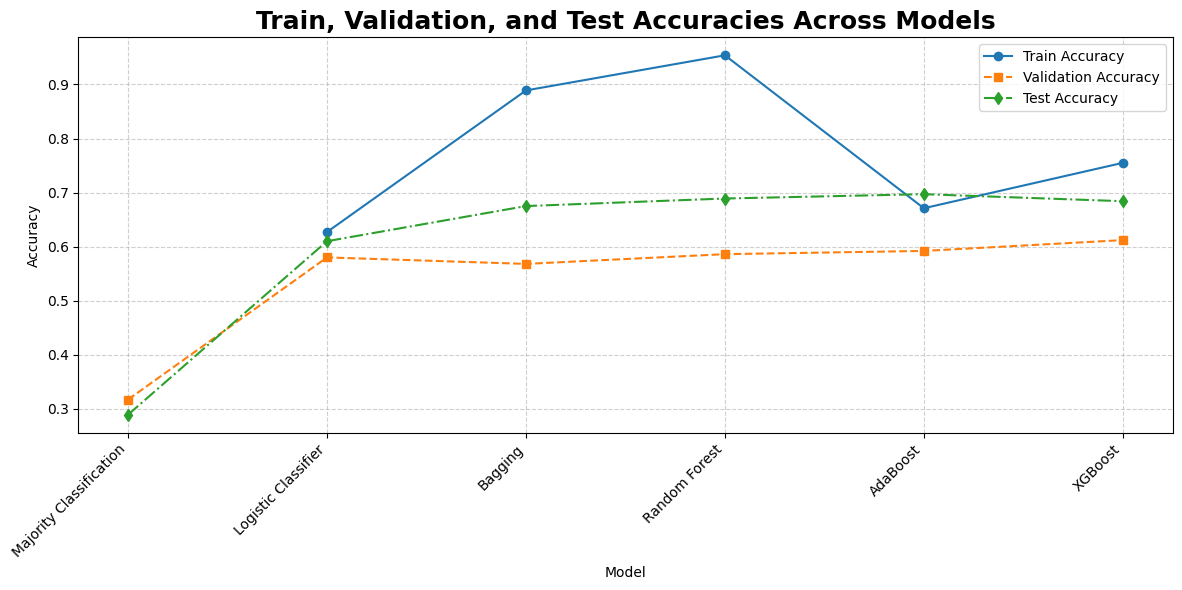

In [110]:
# Create the line plot
plt.figure(figsize=(12, 6))

plt.plot(model_results_df.index, model_results_df['Train Accuracy'], label='Train Accuracy', marker='o', linestyle='-')
plt.plot(model_results_df.index, model_results_df['Validation Accuracy'], label='Validation Accuracy', marker='s', linestyle='--')
plt.plot(model_results_df.index, model_results_df['Test Accuracy'], label='Test Accuracy', marker='d', linestyle='-.')

# Add labels, legend, and title
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Train, Validation, and Test Accuracies Across Models', fontsize=18, fontweight='bold')
plt.xticks(ticks=range(len(model_results_df.index)), labels=model_results_df['Model Name'], rotation=45, ha='right')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Show the plot
plt.show()

Once again, the plot above demonstrates how XGBoost test accuracy is best.

# SECTION 6: CONCLUSION

In this project, we aimed to develop the most accurate predictive model for projecting individual race finishing results in the hybrid era of Formula One (F1) racing, exceeding the 70% accuracy test accuracy threshold. After preprocessing our data, we engineered several new predictor variables to quantify team, car, and driver performance, as well as a novel response variable, position bucket. This ordinal target variable classified the field of F1 drivers in each race into quartiles, enabling us to analyze performance in a structured way.

With this framework, we developed six distinct models: majority classification, logistic regression, bagging regressor, random forest regressor, AdaBoost, and XGBoost. To avoid multicollinearity, we selected a curated subset of predictors that best represented the drivers' performance after conducting exploratory data analysis. Notably, starting position (grid), elo scores (historical performance), and laps completed (an indicator of whether a driver finished the race) consistently emerged as the strongest predictors across models 4.3 to 4.7. In total, we utilized 12 of the original 43 predictors to optimize model performance, and our boosting models performed the strongest with respect to test accuracy.

XGBoost was the ultimate winner, recording a test accuracy of 70.2%. For consistency, we kept our choice of predictors uniform after initializing our majority classification baseline, but when removing historical performance metrics from our random forest model, we did register 71%; however, elo scores improved the performance of every other model, so we decided to retain it as a predictor for consistency and effective model comparison.

We speculate that our boosting models performed the best on the 2023 validation and 2024 test set because they were better equipped to capture the nuanced relationships inherent in the ordinal target variable, position bucket. XGBoost and AdaBoost iteratively correct errors made by previous models, allowing them to handle complex decision boundaries that enabled us to break our desired accuracy threshold. These models also benefit from their ability to prioritize important features during training, which likely helped emphasize the strongest predictors. Furthermore, the robustness of boosting models in managing imbalanced data and handling outliers may have contributed to their superior performance, particularly in cases where race outcomes were influenced by unexpected events such as crashes, mechanical failures, or extreme weather conditions that we were unable to model due to data limitations.

Moreover, the boosting models offered an effective tradeoff between bias and variance, reducing underfitting while maintaining generalizability to unseen data. Ultimately, XGBoost's flexibility and precision enabled it to achieve the highest accuracy, affirming its suitability for predictive modeling in F1's hybrid era.

In the future, we hope to better model in-race strategy by incorporating team decisions, such as tire choice (soft, medium, hard, wet, etc.) at different points in the race. This could allow us to better measure constructor ability and thereby improve accuracy. Furthermore, we aim to refine our Elo score calculation. While we currently calculate Elo scores for each driver, more advanced analytical methods—such as van Kesteren and Bergkamp's (2022) Bayesian Rank-Ordered Logit—could better quantify driver and car ability based on previous results. Lastly, while most variables we considered are endogenous to race results (e.g., grid position and pit stop duration), there is a range of exogenous data that could be collected and incorporated, such as weather conditions and track type (permanent circuit vs. street circuit). Our primary challenge in implementing these changes will be data collection. However, given the growing popularity of F1 and the sport's highly technological nature, we are optimistic about increasing our model's test accuracy by identifying and incorporating these new predictors, which we believe will be essential for improving future outcomes.

# SECTION 7: ACKNOWLEDGEMENTS

Acknowledgment: We would like to give special thanks to Yuan Tang, who helped us shape our modeling pipeline and motivate our video presentation. His help proved instrumental in our final model forumalation, and we have sincerely appreciated his investment in our project.

We would also like to thank the CS1090A: Data Science 1 course staff. Many of our models were inspired by the Python notebooks and resources provided throughout the course. These materials were invaluable to our learning, and we are thankful to have had the opportunity to grow as data scientists over the course of this semester.